# **Torsional Oscillator**

In [2]:
#Import Statements- These tell the python compiler about packages that it needs to use. 
#It is good practice to note which pieces of a package you use with a comment, 
#so that you know where they are for future reference. They are included here for just that.
import numpy as np #I use numpy for most things. It plays well with other things, and I find it avoids data type conflicts well
from numpy import genfromtxt #This will help read in a data file as a numpy array
from scipy.optimize import curve_fit #This will help us do nonlinear least squares fitting.

import matplotlib.pyplot as plt #This allows you to plot things using the Matplotlib library. 

from IPython.display import display, Latex

## Calibrate the Voltage Reading to the Angular Position

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

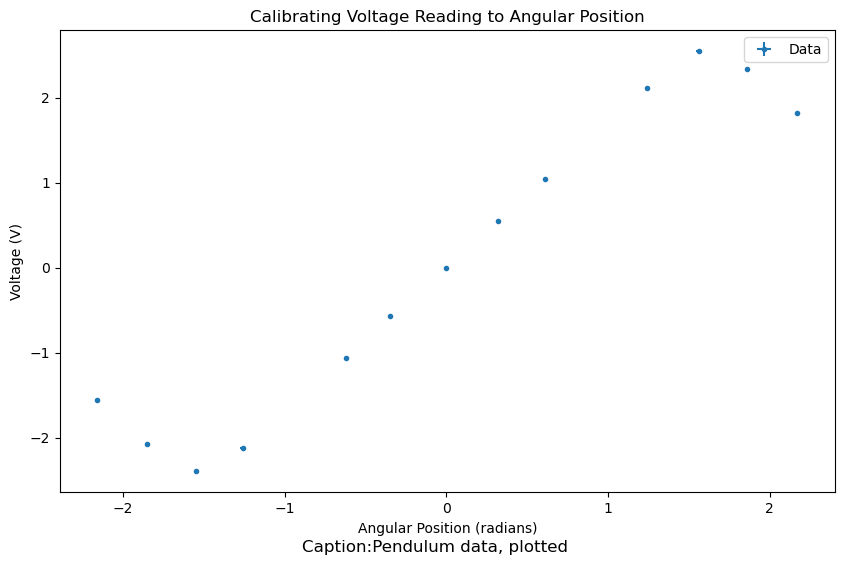

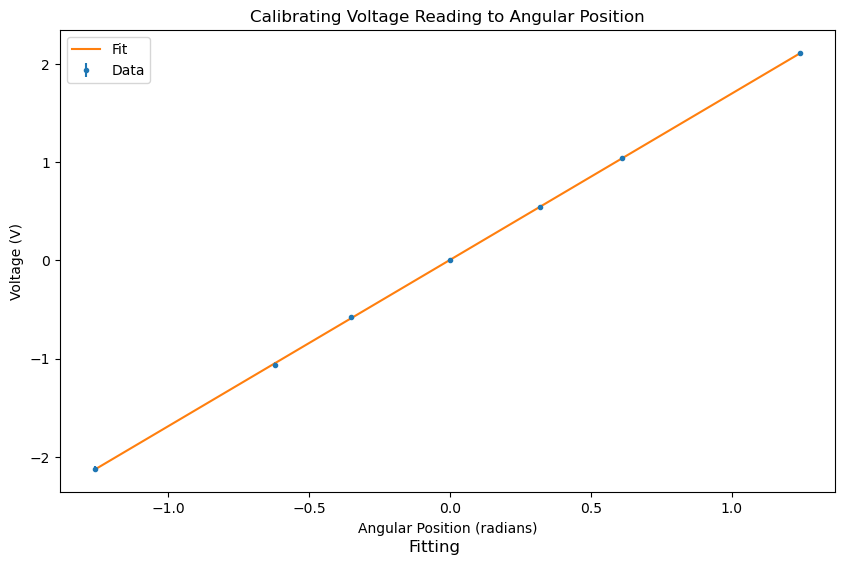

In [17]:
#KEY REMOVE FOR STUDENTS
#Import "linear_response_and_calibration.txt"
data= genfromtxt("linear_response_and_calibration.txt", delimiter=' ',skip_header=1)
theta_raw = data[:, 0] - 2.99
theta_error_raw = np.sqrt(2 * (data[:, 1])**2)
V_raw = data[:, 2]
V_error_raw = data[:, 3]
theta = theta_raw[3:10]
theta_error = theta_error_raw[3:10]
V = V_raw[3:10]
V_error = V_error_raw[3:10]


#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(theta_raw, V_raw, xerr=theta_error_raw, yerr=V_error_raw, fmt='.', label="Data")
plt.legend()
plt.xlabel('Angular Position (radians)')
plt.ylabel('Voltage (V)')
plt.title('Calibrating Voltage Reading to Angular Position')
plt.figtext(0.5, 0.01, "Caption:Pendulum data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def V_to_theta(x, m, b):
    y = m * x + b
    return y

#Preliminarily Fit the Data
guess_m = 2
guess_b = 0


guess=np.array([guess_m, guess_b])

uw_fits,uw_covs=curve_fit(V_to_theta, theta, V, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate total error
sigmas= np.sqrt(V_error**2 + (uw_fits[0] * theta_error)**2)

#Perform weighted fit
fits, covs=curve_fit(V_to_theta, theta, V, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (theta.size - 2.0)) * np.sum(((V - V_to_theta(theta, fits[0], fits[1])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2$ =  {Red_chi_sq}"))
display(Latex(fr"$m = {fits[0]:.3f} \pm {stds[0]:.3f}$"))
display(Latex(fr"$b = {fits[1]:.3f} \pm {stds[1]:.3f}$"))
                 

#Plot the fit with the data!
fit_V = V_to_theta(theta, fits[0], fits[1])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(theta, V, yerr=sigmas, fmt='.', label="Data")
plt.plot(theta, fit_V, '-', label="Fit")
plt.legend()
plt.xlabel('Angular Position (radians)')
plt.ylabel('Voltage (V)')
plt.title('Calibrating Voltage Reading to Angular Position')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

## Establish the Linear Response of the Restoring Torque

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

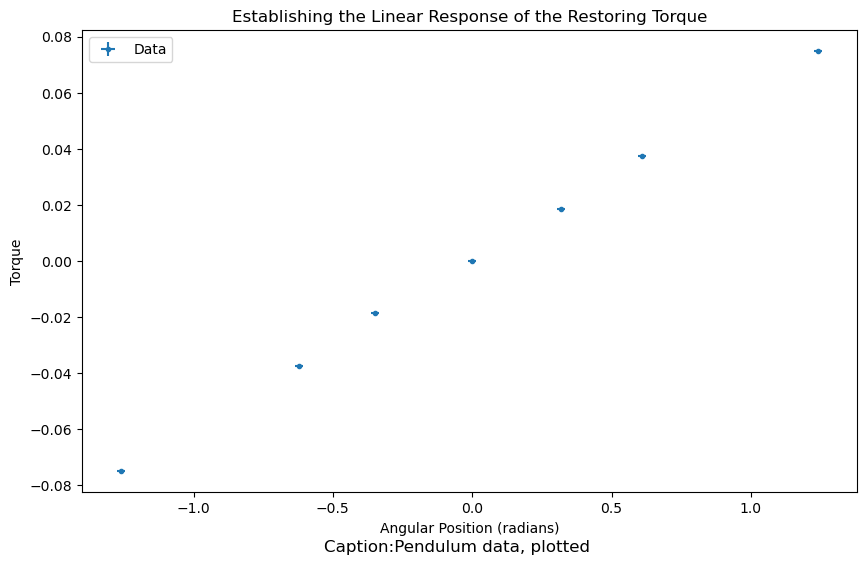

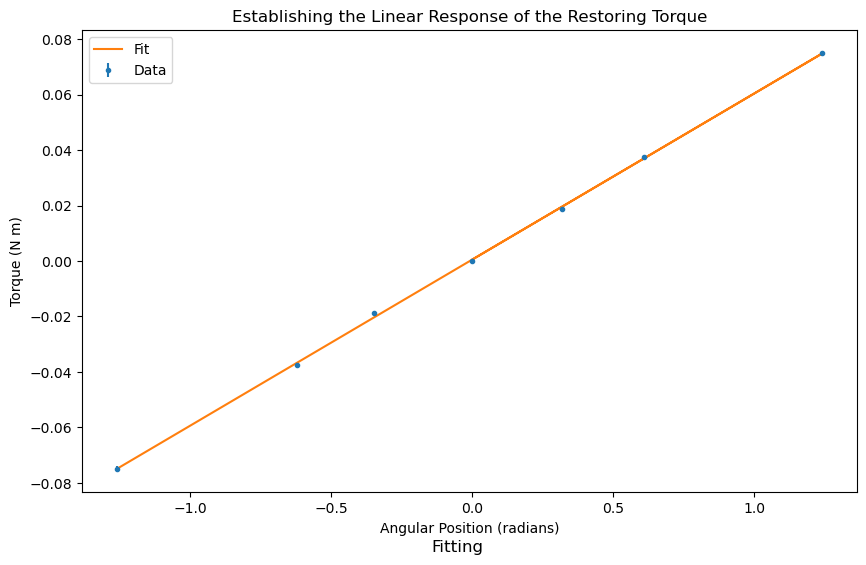

In [ ]:
#KEY REMOVE FOR STUDENTS
#Import "linear_response_and_calibration.txt"
data= genfromtxt("linear_response_and_calibration.txt", delimiter=' ',skip_header=1)
theta = data[:, 0] - 2.99
theta_error = np.sqrt(2 * (data[:, 1])**2)
V = data[:, 2]
V_error = data[:, 3]
mass = data[:, 4]
mass_error = data[:, 5]
radius = 0.019095
radius_error = 0.000005
g = 9.8
torque = mass * g * radius
torque_error = np.sqrt((g * radius * mass_error)**2 + (mass * g * radius_error)**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(theta, torque, xerr = theta_error, yerr = torque_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Angular Position (radians)')
plt.ylabel('Torque')
plt.title('Establishing the Linear Response of the Restoring Torque')
plt.figtext(0.5, 0.01, "Caption:Pendulum data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def torque_vs_theta(x, kappa, b):
    y = kappa * x + b
    return y

#Preliminarily Fit the Data
guess_kappa = 0.08
guess_b = 0


guess=np.array([guess_kappa, guess_b])

uw_fits,uw_covs=curve_fit(torque_vs_theta, theta, torque, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate total error
sigmas= np.sqrt(torque_error**2 + (uw_fits[0] * theta_error)**2)

#Perform weighted fit
fits, covs=curve_fit(torque_vs_theta, theta, torque, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (theta.size - 2.0)) * np.sum(((torque - torque_vs_theta(theta, fits[0], fits[1])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$\kappa = {fits[0]:.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$b = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
                 

#Plot the fit with the data!
fit_torque = torque_vs_theta(theta, fits[0], fits[1])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(theta, torque, yerr=sigmas, fmt='.', label="Data")
plt.plot(theta, fit_torque, '-', label="Fit")
plt.legend()
plt.xlabel('Angular Position (radians)')
plt.ylabel("Torque (N m)")
plt.title('Establishing the Linear Response of the Restoring Torque')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

## Order-of-Magnitude Estimation of the Moment of Inertia of the Rotor

In [72]:
# Calculate I_Al
r_Al = 0.013 # m
h_Al = 0.220 # m
V_Al = np.pi * r_Al**2 * h_Al # m^3
rho_Al = 2700 # kg / m^3
m_Al = rho_Al * V_Al # kg
I_Al = (1 / 2) * m_Al * r_Al**2 # kg * m^2

display(Latex(fr"$\text{{Moment of Inertia of Aluminum Shaft}} = {I_Al:.6f} \text{{ kg}} \cdot \text{{m}}^{{2}}$"))

# Calculate I_Cu
r_Cu = 0.01272 # m
R_Cu = 0.06275 # m
h_Cu = 0.0097 # m
V_Cu = np.pi * (R_Cu**2 - r_Cu**2) * h_Cu # m^3
rho_Cu = 8960 # kg / m^3
m_Cu = rho_Cu * V_Cu # kg
I_Cu = (1 / 2) * m_Cu * (R_Cu**2 + r_Cu**2) # kg * m^2

display(Latex(fr"$\text{{Moment of Inertia of Copper Annulus}} = {I_Cu:.4f} \text{{ kg}} \cdot \text{{m}}^{{2}}$"))

# Calculate I
I = I_Al + I_Cu # kg * m^2
display(Latex(fr"$\text{{Moment of Inertia of Rotor}} = {I:.4f} \text{{ kg}} \cdot \text{{m}}^{{2}}$"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## Fit and Verify that the Motion is Sinusoidal in Nature

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

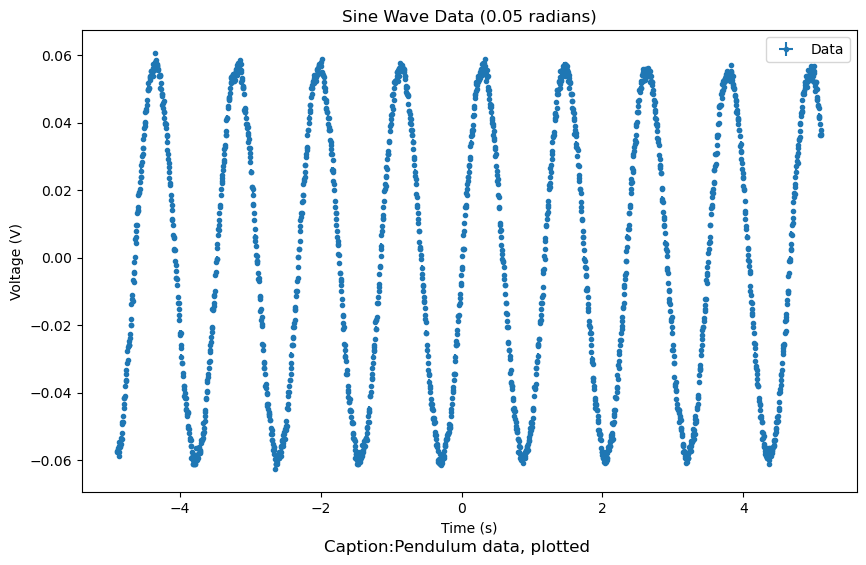

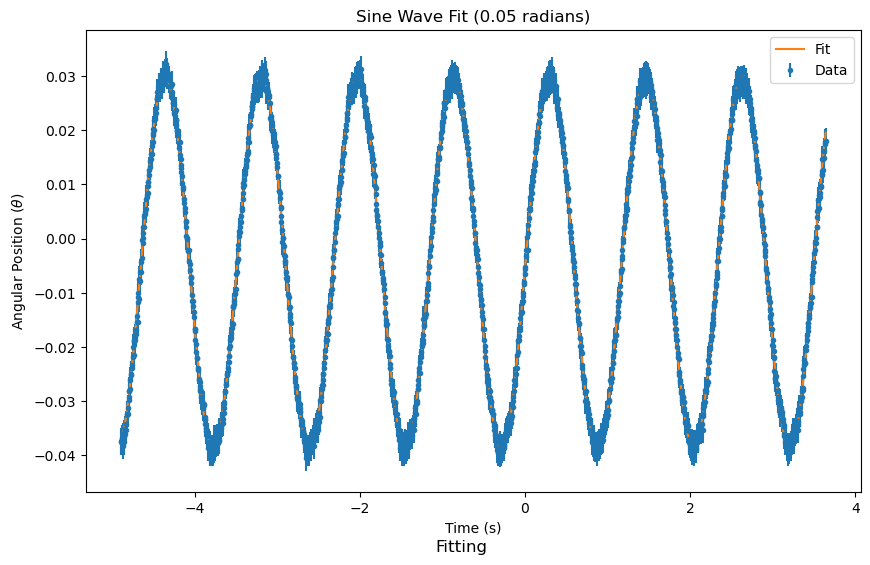

In [ ]:
#KEY REMOVE FOR STUDENTS
#Import "SineWave_0.05radians.txt"
data= genfromtxt("SineWave_0.05radians.txt", delimiter='	', skip_header=1, invalid_raise=False)
t_raw = data[:, 0] 
t_error = 0.0025
V_raw = data[:, 1]
V_error = 0.003675 / 6
t_range = t_raw[0:1707]
V_range = V_raw[0:1707]

mask = ~np.isnan(t_range) & ~np.isnan(V_range)
t = t_range[mask]
V = V_range[mask]

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t_raw, V_raw, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Sine Wave Data (0.05 radians)')
plt.figtext(0.5, 0.01, "Caption:Pendulum data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def sine_wave1(x, A, omega, phi0, C):
    y = A * np.sin(omega * x + phi0) + C
    return y

#Preliminarily Fit the Data
guess_A = 0.06
guess_omega = 5
guess_phi0 = -2.8
guess_C = -0.02


guess=np.array([guess_A, guess_omega, guess_phi0, guess_C])

uw_fits,uw_covs=curve_fit(sine_wave1, t, theta, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = uw_fits[1] * uw_fits[0] * np.cos(uw_fits[1] * t + uw_fits[2])

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(sine_wave1, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 4.0)) * np.sum(((theta - sine_wave1(t, fits[0], fits[1], fits[2], fits[3])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.5f} \pm {stds[0]:.5f}$"))
display(Latex(fr"$\omega = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$\phi_0 = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$C = {fits[3]:.4f} \pm {stds[3]:.5f}$"))

#Plot the fit with the data!
fit_theta = sine_wave1(t, fits[0], fits[1], fits[2], fits[3])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_theta, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (0.05 radians)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

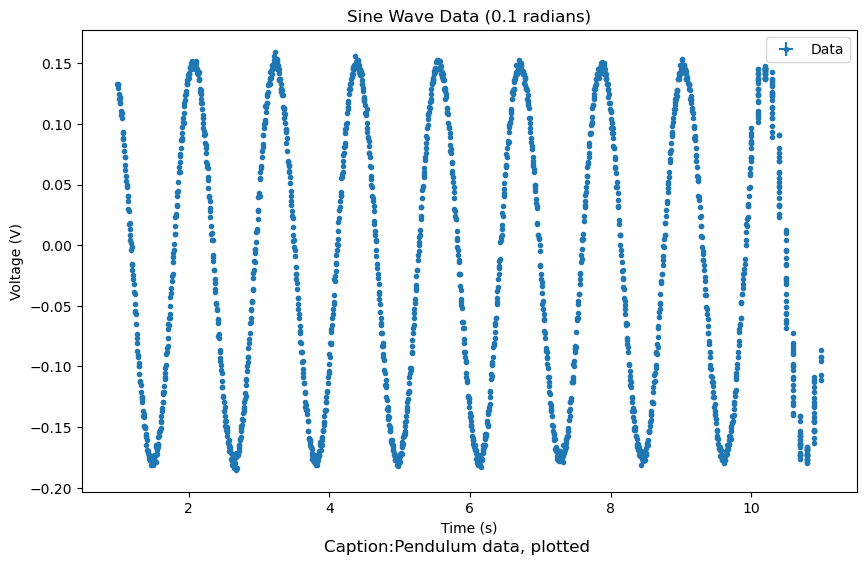

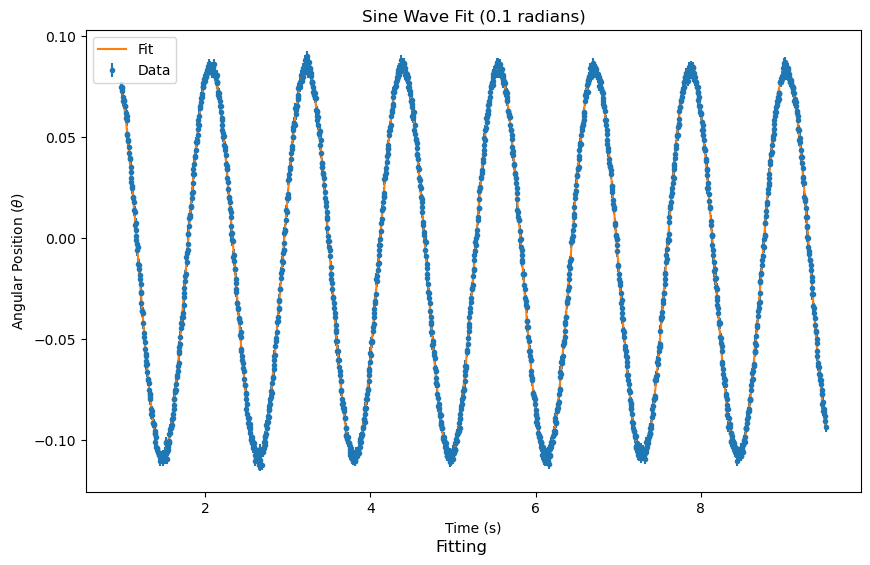

In [2]:
#KEY REMOVE FOR STUDENTS
#Import "SineWave_0.1radians.txt"
data= genfromtxt("SineWave_0.1radians.txt", delimiter='	', skip_header=1, invalid_raise=False)
t_raw = data[:, 0] 
t_error = 0.0025
V_raw = data[:, 1]
V_error = 0.007175 / 6
t_range = t_raw[0:1707]
V_range = V_raw[0:1707]

mask = ~np.isnan(t_range) & ~np.isnan(V_range)
t = t_range[mask]
V = V_range[mask]

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t_raw, V_raw, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Sine Wave Data (0.1 radians)')
plt.figtext(0.5, 0.01, "Caption:Pendulum data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def sine_wave1(x, A, omega, phi0, C):
    y = A * np.sin(omega * x + phi0) + C
    return y

#Preliminarily Fit the Data
guess_A = 0.17
guess_omega = 4.83
guess_phi0 = -2.8
guess_C = -0.02


guess=np.array([guess_A, guess_omega, guess_phi0, guess_C])

uw_fits,uw_covs=curve_fit(sine_wave1, t, theta, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = uw_fits[1] * uw_fits[0] * np.cos(uw_fits[1] * t + uw_fits[2])

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(sine_wave1, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 4.0)) * np.sum(((theta - sine_wave1(t, fits[0], fits[1], fits[2], fits[3])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$\omega = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$\phi_0 = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$C = {fits[3]:.4f} \pm {stds[3]:.5f}$"))

#Plot the fit with the data!
fit_theta = sine_wave1(t, fits[0], fits[1], fits[2], fits[3])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_theta, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (0.1 radians)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

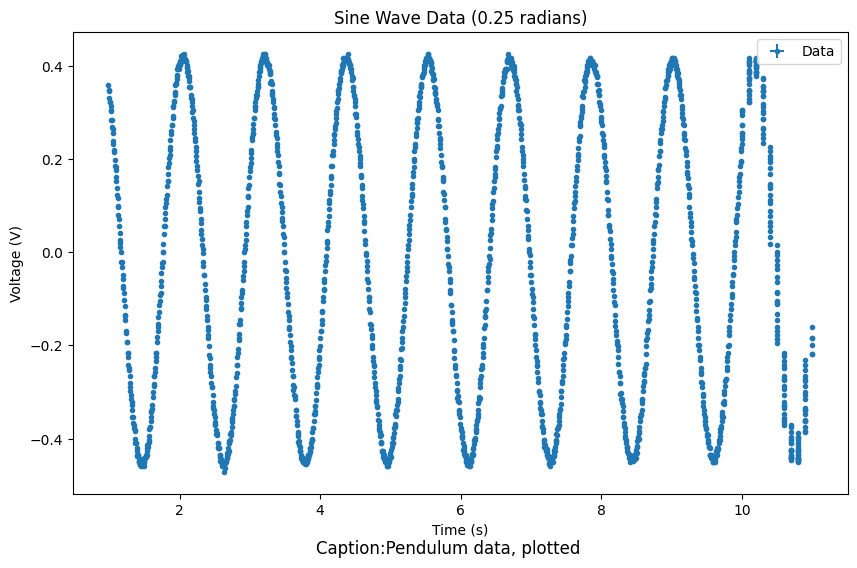

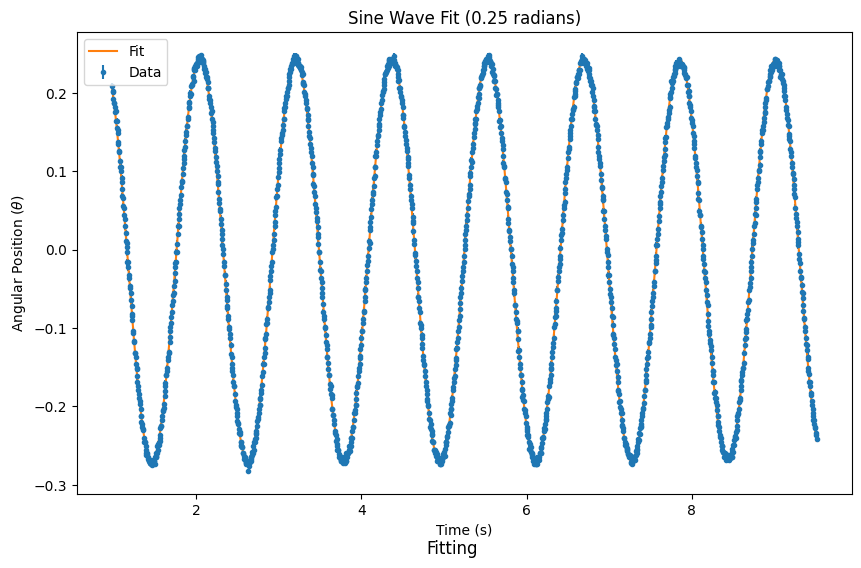

In [18]:
#KEY REMOVE FOR STUDENTS
#Import "SineWave_0.25radians.txt"
data= genfromtxt("SineWave_0.25radians.txt", delimiter='	', skip_header=1, invalid_raise=False)
t_raw = data[:, 0] 
t_error = 0.0025
V_raw = data[:, 1]
V_error = 0.010075 / 6
t_range = t_raw[0:1707]
V_range = V_raw[0:1707]

mask = ~np.isnan(t_range) & ~np.isnan(V_range)
t = t_range[mask]
V = V_range[mask]

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t_raw, V_raw, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Sine Wave Data (0.25 radians)')
plt.figtext(0.5, 0.01, "Caption:Pendulum data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def sine_wave1(x, A, omega, phi0, C):
    y = A * np.sin(omega * x + phi0) + C
    return y

#Preliminarily Fit the Data
guess_A = 0.17
guess_omega = 5.4
guess_phi0 = -2.8
guess_C = -0.02


guess=np.array([guess_A, guess_omega, guess_phi0, guess_C])

uw_fits,uw_covs=curve_fit(sine_wave1, t, theta, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = uw_fits[1] * uw_fits[0] * np.cos(uw_fits[1] * t + uw_fits[2])

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(sine_wave1, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 4.0)) * np.sum(((theta - sine_wave1(t, fits[0], fits[1], fits[2], fits[3])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$\omega = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$\phi_0 = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$C = {fits[3]:.4f} \pm {stds[3]:.4f}$"))

#Plot the fit with the data!
fit_theta = sine_wave1(t, fits[0], fits[1], fits[2], fits[3])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_theta, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (0.25 radians)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

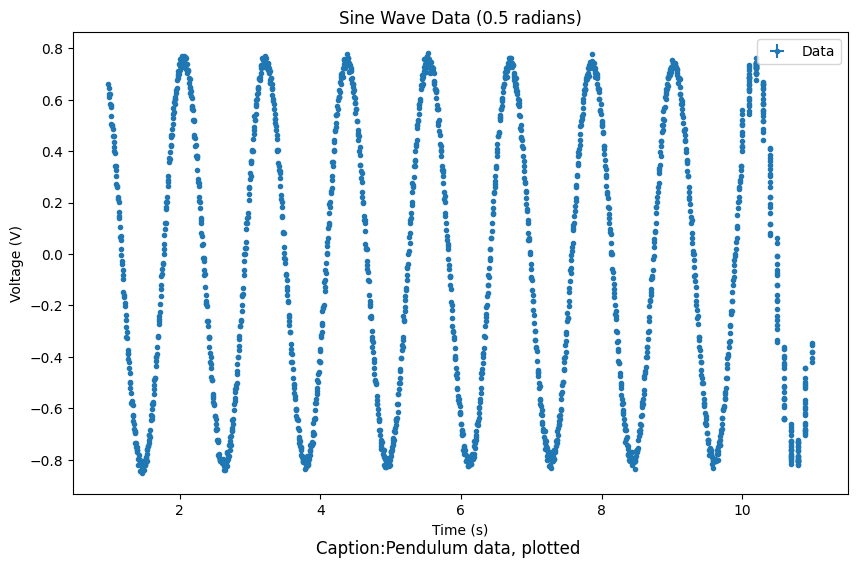

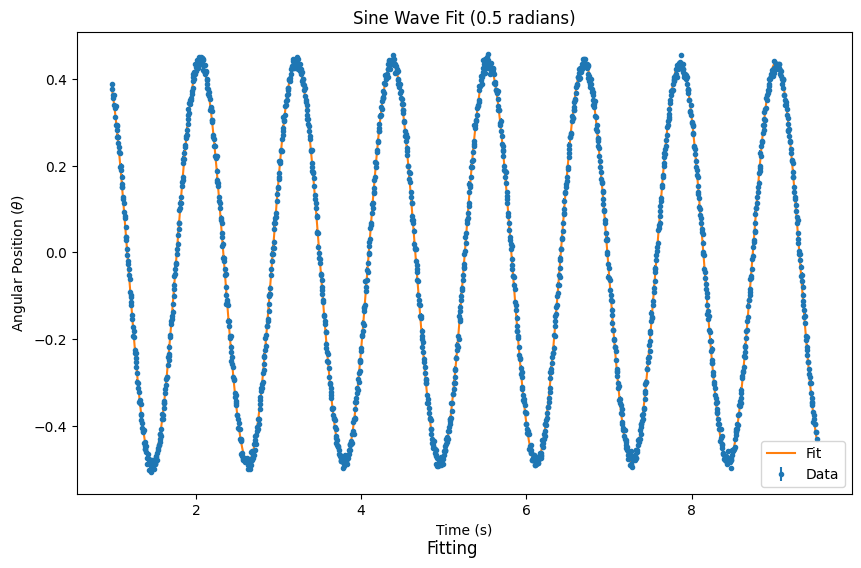

In [20]:
#KEY REMOVE FOR STUDENTS
#Import "SineWave_0.5radians.txt"
data= genfromtxt("SineWave_0.5radians.txt", delimiter='	', skip_header=1, invalid_raise=False)
t_raw = data[:, 0] 
t_error = 0.0025
V_raw = data[:, 1]
V_error = 0.005100 / 6
t_range = t_raw[0:1707]
V_range = V_raw[0:1707]

mask = ~np.isnan(t_range) & ~np.isnan(V_range)
t = t_range[mask]
V = V_range[mask]

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t_raw, V_raw, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Sine Wave Data (0.5 radians)')
plt.figtext(0.5, 0.01, "Caption:Pendulum data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def sine_wave1(x, A, omega, phi0, C):
    y = A * np.sin(omega * x + phi0) + C
    return y

#Preliminarily Fit the Data
guess_A = 0.17
guess_omega = 5.4
guess_phi0 = -2.8
guess_C = -0.02


guess=np.array([guess_A, guess_omega, guess_phi0, guess_C])

uw_fits,uw_covs=curve_fit(sine_wave1, t, theta, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = uw_fits[1] * uw_fits[0] * np.cos(uw_fits[1] * t + uw_fits[2])

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(sine_wave1, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 4.0)) * np.sum(((theta - sine_wave1(t, fits[0], fits[1], fits[2], fits[3])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$\omega = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$\phi_0 = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$C = {fits[3]:.4f} \pm {stds[3]:.4f}$"))

#Plot the fit with the data!
fit_sine = sine_wave1(t, fits[0], fits[1], fits[2], fits[3])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_sine, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (0.5 radians)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

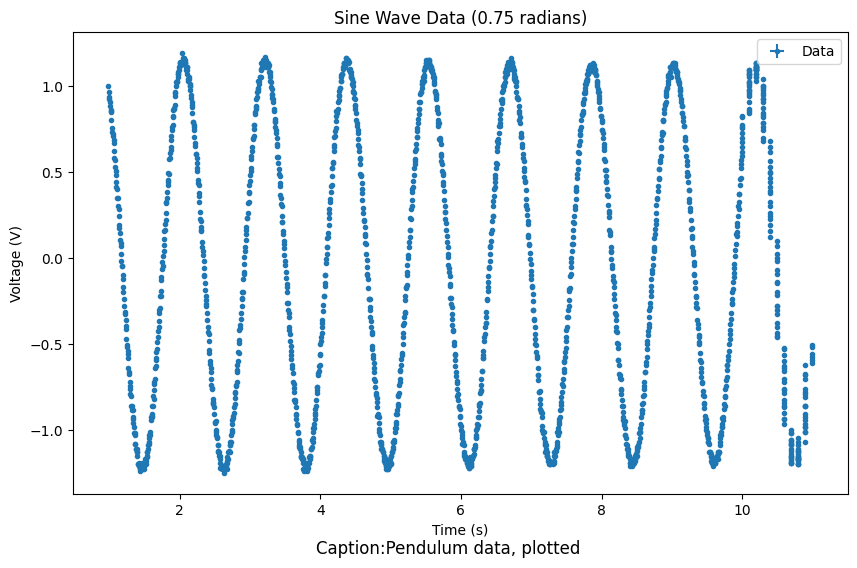

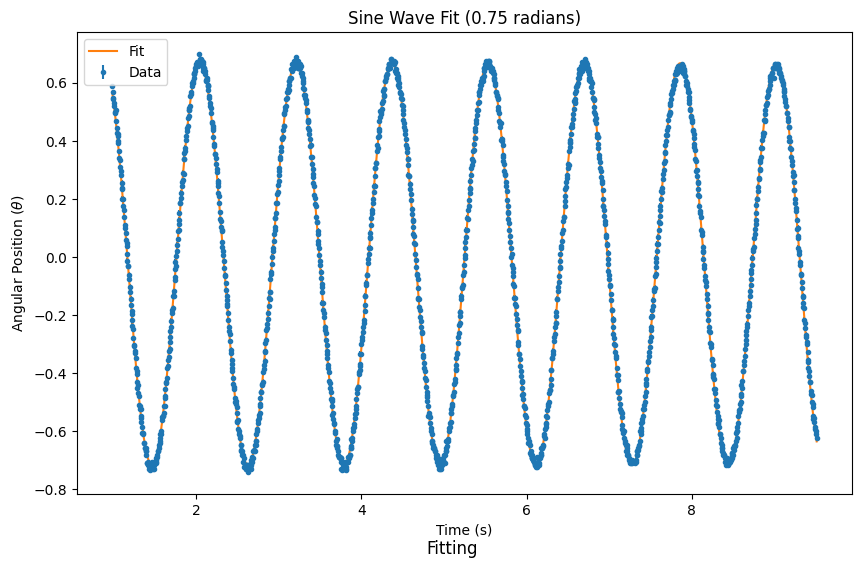

In [21]:
#KEY REMOVE FOR STUDENTS
#Import "SineWave_0.75radians.txt"
data= genfromtxt("SineWave_0.75radians.txt", delimiter='	', skip_header=1, invalid_raise=False)
t_raw = data[:, 0] 
t_error = 0.0025
V_raw = data[:, 1]
V_error = 0.004300 / 6
t_range = t_raw[0:1707]
V_range = V_raw[0:1707]

mask = ~np.isnan(t_range) & ~np.isnan(V_range)
t = t_range[mask]
V = V_range[mask]

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t_raw, V_raw, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Sine Wave Data (0.75 radians)')
plt.figtext(0.5, 0.01, "Caption:Pendulum data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def sine_wave1(x, A, omega, phi0, C):
    y = A * np.sin(omega * x + phi0) + C
    return y

#Preliminarily Fit the Data
guess_A = 0.17
guess_omega = 5.4
guess_phi0 = -2.8
guess_C = -0.02


guess=np.array([guess_A, guess_omega, guess_phi0, guess_C])

uw_fits,uw_covs=curve_fit(sine_wave1, t, theta, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = uw_fits[1] * uw_fits[0] * np.cos(uw_fits[1] * t + uw_fits[2])

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(sine_wave1, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 4.0)) * np.sum(((theta - sine_wave1(t, fits[0], fits[1], fits[2], fits[3])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$\omega = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$\phi_0 = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$C = {fits[3]:.4f} \pm {stds[3]:.4f}$"))

#Plot the fit with the data!
fit_sine = sine_wave1(t, fits[0], fits[1], fits[2], fits[3])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_sine, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (0.75 radians)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

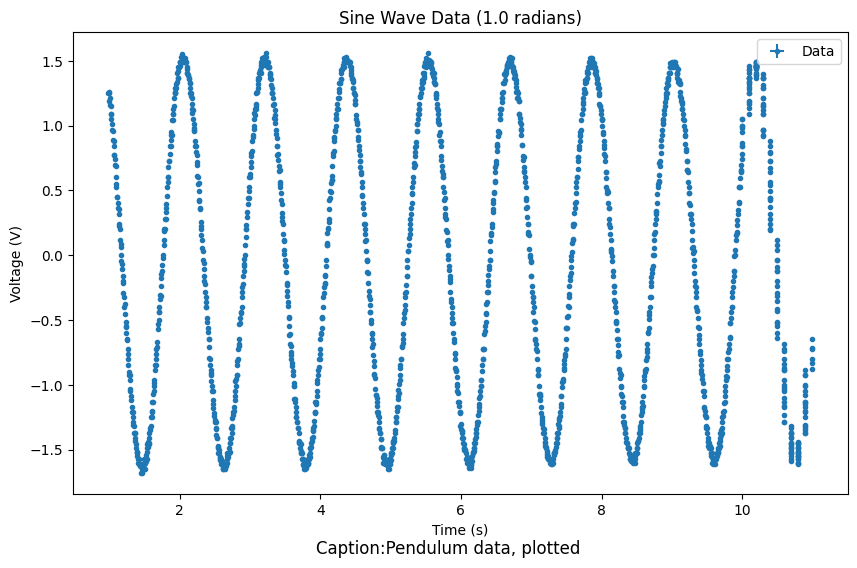

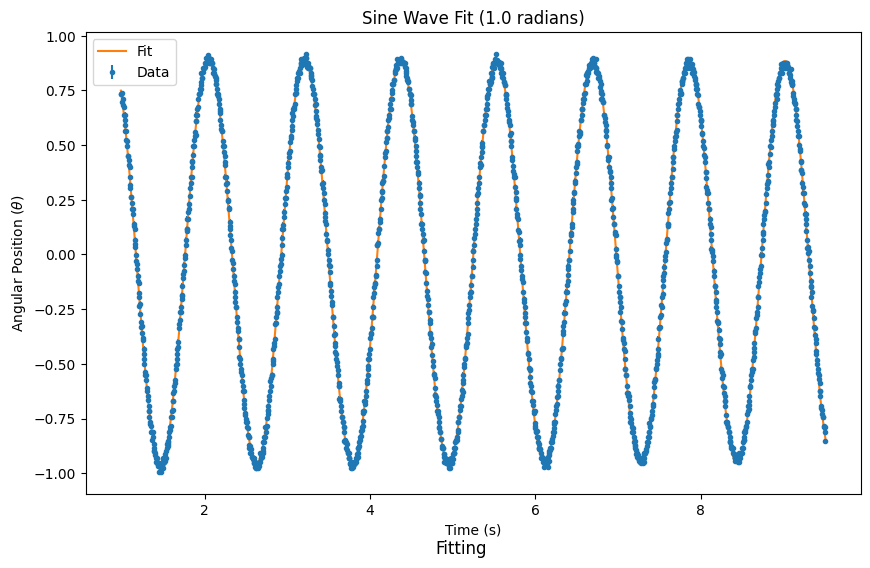

In [22]:
#KEY REMOVE FOR STUDENTS
#Import "SineWave_1.0radians.txt"
data= genfromtxt("SineWave_1.0radians.txt", delimiter='	', skip_header=1, invalid_raise=False)
t_raw = data[:, 0] 
t_error = 0.0025
V_raw = data[:, 1]
V_error = 0.004600 / 6
t_range = t_raw[0:1707]
V_range = V_raw[0:1707]

mask = ~np.isnan(t_range) & ~np.isnan(V_range)
t = t_range[mask]
V = V_range[mask]

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t_raw, V_raw, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Sine Wave Data (1.0 radians)')
plt.figtext(0.5, 0.01, "Caption:Pendulum data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def sine_wave1(x, A, omega, phi0, C):
    y = A * np.sin(omega * x + phi0) + C
    return y

#Preliminarily Fit the Data
guess_A = 0.17
guess_omega = 5.4
guess_phi0 = -2.8
guess_C = -0.02


guess=np.array([guess_A, guess_omega, guess_phi0, guess_C])

uw_fits,uw_covs=curve_fit(sine_wave1, t, theta, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = uw_fits[1] * uw_fits[0] * np.cos(uw_fits[1] * t + uw_fits[2])

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(sine_wave1, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 4.0)) * np.sum(((theta - sine_wave1(t, fits[0], fits[1], fits[2], fits[3])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$\omega = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$\phi_0 = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$C = {fits[3]:.4f} \pm {stds[3]:.4f}$"))

#Plot the fit with the data!
fit_sine = sine_wave1(t, fits[0], fits[1], fits[2], fits[3])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_sine, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (1.0 radians)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

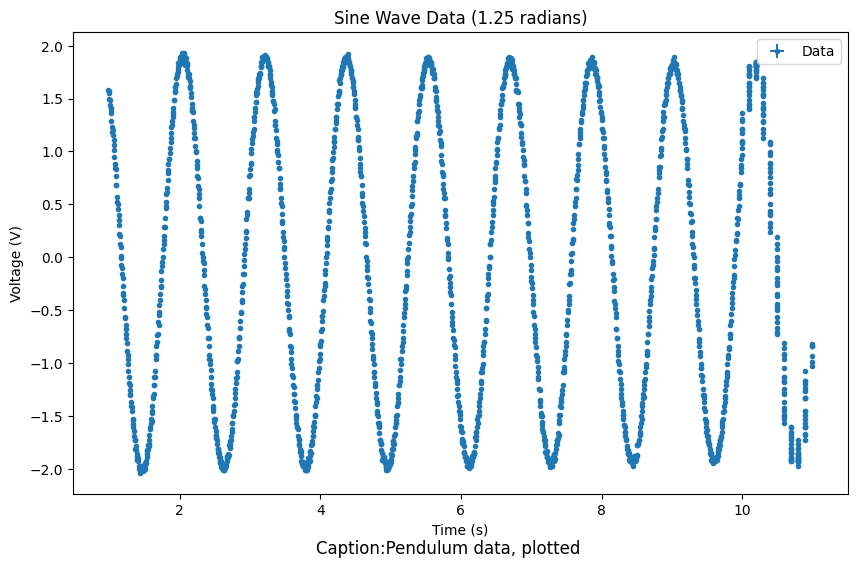

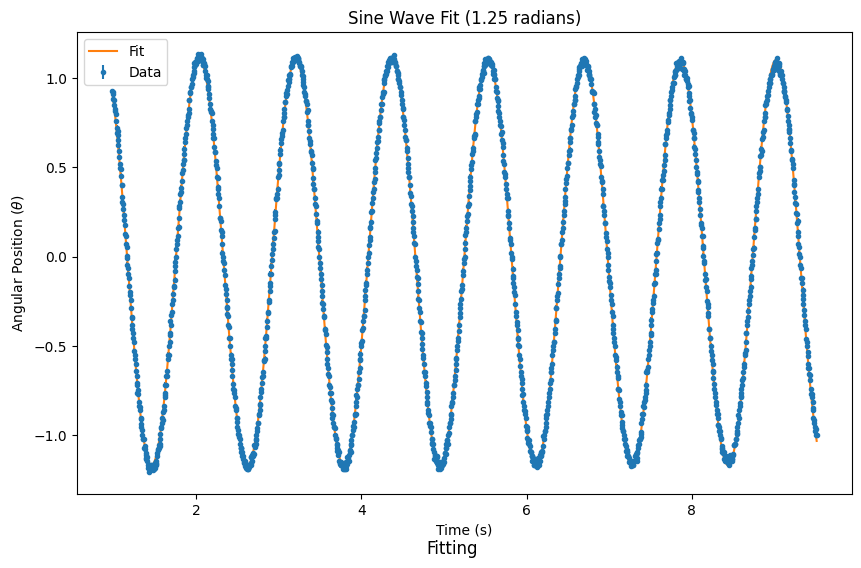

In [23]:
#KEY REMOVE FOR STUDENTS
#Import "SineWave_1.25radians.txt"
data= genfromtxt("SineWave_1.25radians.txt", delimiter='	', skip_header=1, invalid_raise=False)
t_raw = data[:, 0] 
t_error = 0.0025
V_raw = data[:, 1]
V_error = 0.004600 / 6
t_range = t_raw[0:1707]
V_range = V_raw[0:1707]

mask = ~np.isnan(t_range) & ~np.isnan(V_range)
t = t_range[mask]
V = V_range[mask]

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t_raw, V_raw, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Sine Wave Data (1.25 radians)')
plt.figtext(0.5, 0.01, "Caption:Pendulum data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def sine_wave1(x, A, omega, phi0, C):
    y = A * np.sin(omega * x + phi0) + C
    return y

#Preliminarily Fit the Data
guess_A = 0.17
guess_omega = 5.4
guess_phi0 = -2.8
guess_C = -0.02


guess=np.array([guess_A, guess_omega, guess_phi0, guess_C])

uw_fits,uw_covs=curve_fit(sine_wave1, t, theta, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = uw_fits[1] * uw_fits[0] * np.cos(uw_fits[1] * t + uw_fits[2])

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(sine_wave1, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 4.0)) * np.sum(((theta - sine_wave1(t, fits[0], fits[1], fits[2], fits[3])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$\omega = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$\phi_0 = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$C = {fits[3]:.4f} \pm {stds[3]:.4f}$"))

#Plot the fit with the data!
fit_sine = sine_wave1(t, fits[0], fits[1], fits[2], fits[3])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_sine, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (1.25 radians)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

### Get a quantitative measure of how independent the torsional oscillator is of the amplitude

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

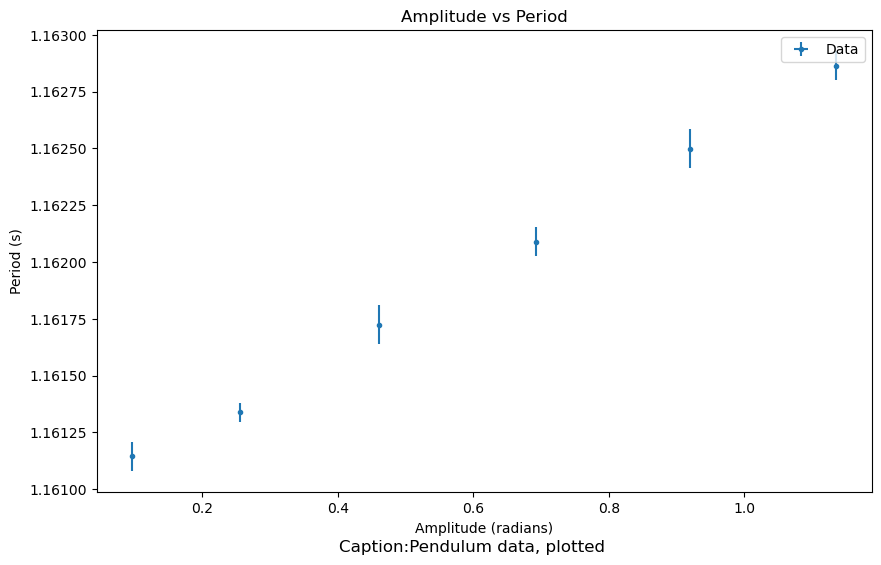

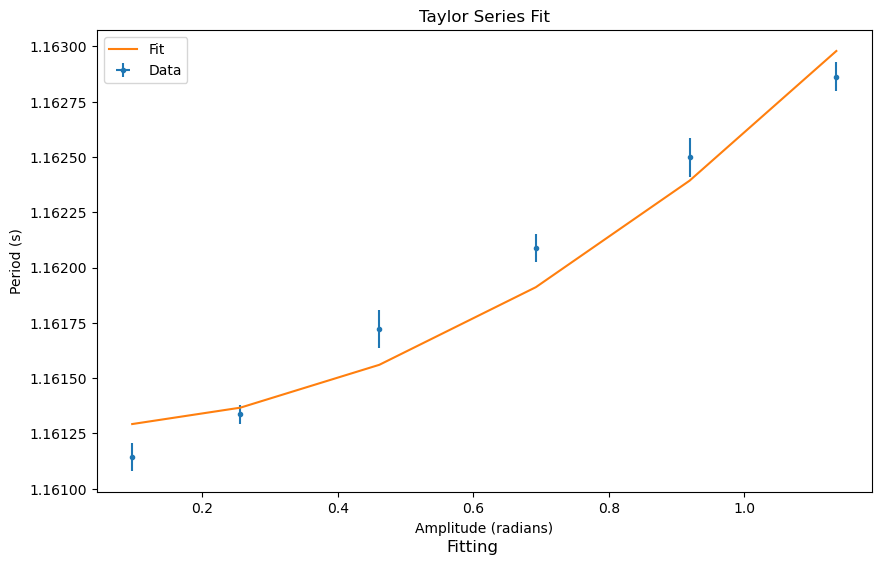

In [ ]:
#KEY REMOVE FOR STUDENTS
#Import "angular_frequency_vs_amplitude.txt"
data= genfromtxt("angular_frequency_vs_amplitude.txt", delimiter=' ', skip_header=1, invalid_raise=False)
omega = data[:, 0] 
omega_error = data[:, 1]
A = data[:, 2]
A_error = data[:, 3]

T = (2 * np.pi) / omega
T_error = ((2 * np.pi) / omega**2) * omega_error

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(A, T, xerr=A_error, yerr=T_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Amplitude (radians)')
plt.ylabel('Period (s)')
plt.title('Amplitude vs Period')
plt.figtext(0.5, 0.01, "Caption:Pendulum data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Taylor_series(x, T0, C):
    y = T0 * (1 + C * x**2)
    return y

#Preliminarily Fit the Data
guess_T0 = 1.16
guess_C = 0.0625


guess=np.array([guess_T0, guess_C])

uw_fits,uw_covs=curve_fit(Taylor_series, A, T, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = uw_fits[0] * 2 * uw_fits[1] * A

#Calculate total error
sigmas= np.sqrt(T_error**2 + (dy_dx * A_error)**2)

#Perform weighted fit
fits, covs=curve_fit(Taylor_series, A, T, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (A.size - 2.0)) * np.sum(((T - Taylor_series(A, fits[0], fits[1])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$T_0 = {fits[0]:.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$C = {fits[1]:.4f} \pm {stds[1]:.4f}$"))

#Plot the fit with the data!
fit_taylor = Taylor_series(A, fits[0], fits[1])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(A, T, xerr=A_error, yerr=T_error, fmt='.', label="Data")
plt.plot(A, fit_taylor, '-', label="Fit")
plt.legend()
plt.xlabel('Amplitude (radians)')
plt.ylabel('Period (s)')
plt.title('Taylor Series Fit')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

### Fit the motion waveform to find how the frequency changes as the $I_{\text{rotor}}$ increases

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

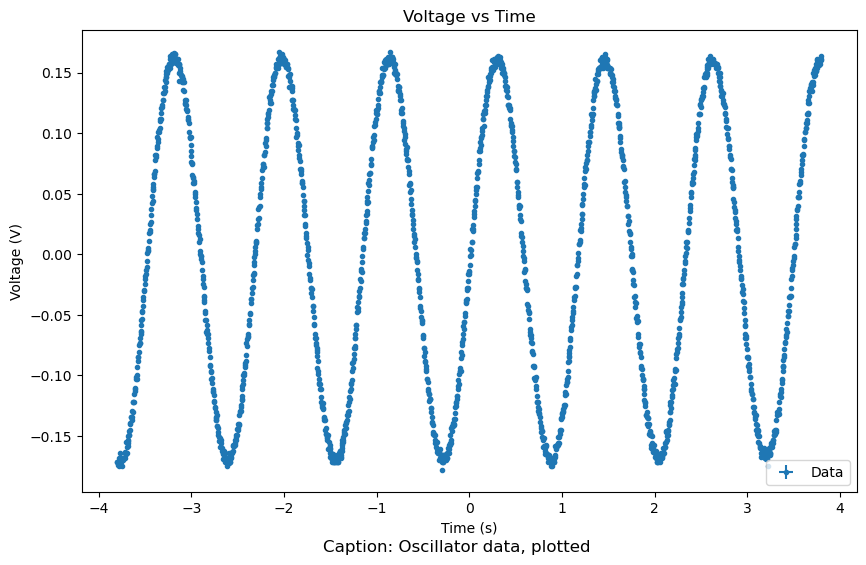

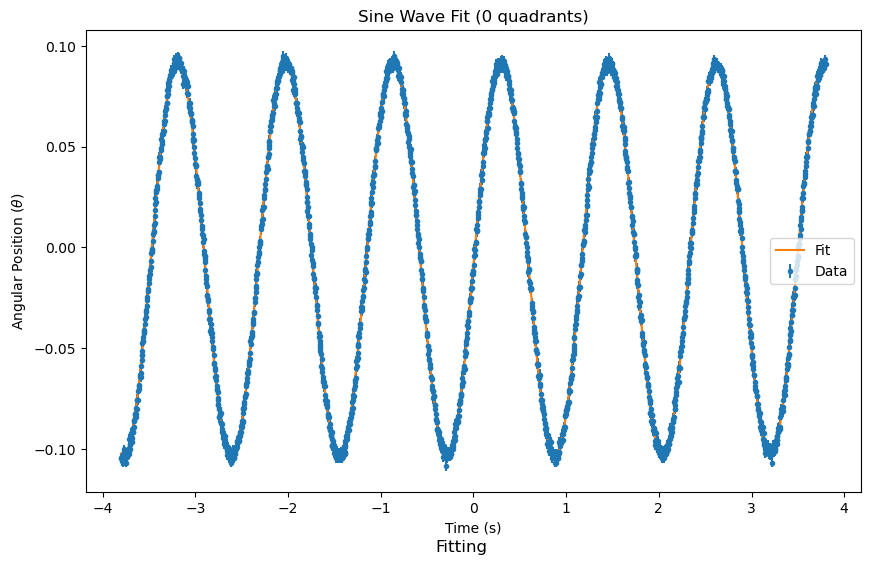

In [9]:
#KEY REMOVE FOR STUDENTS
#Import "0_quadrants.txt"
data = genfromtxt("0_quadrants.txt", delimiter='	', skip_header=2, invalid_raise=False)
t = data[:, 0] 
t_error = 0.0025
V = data[:, 1]
V_error = 0.005000 / 6

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, V, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time')
plt.figtext(0.5, 0.01, "Caption: Oscillator data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def sine_wave_0q(x, A, omega, phi0, C):
    y = A * np.sin(omega * x + phi0) + C
    return y

#Preliminarily Fit the Data
guess_A = 0.17
guess_omega = 5.4
guess_phi0 = -2.8
guess_C = -0.02


guess=np.array([guess_A, guess_omega, guess_phi0, guess_C])

uw_fits,uw_covs=curve_fit(sine_wave_0q, t, theta, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = uw_fits[1] * uw_fits[0] * np.cos(uw_fits[1] * t + uw_fits[2])

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(sine_wave_0q, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 4.0)) * np.sum(((theta - sine_wave_0q(t, fits[0], fits[1], fits[2], fits[3])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$\omega = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$\phi_0 = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$C = {fits[3]:.4f} \pm {stds[3]:.4f}$"))

#Plot the fit with the data!
fit_sine = sine_wave_0q(t, fits[0], fits[1], fits[2], fits[3])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_sine, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (0 quadrants)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

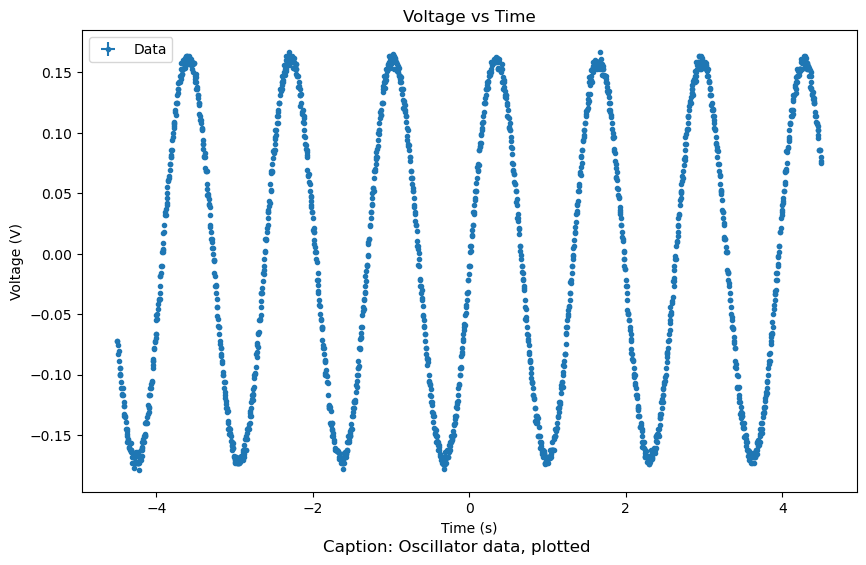

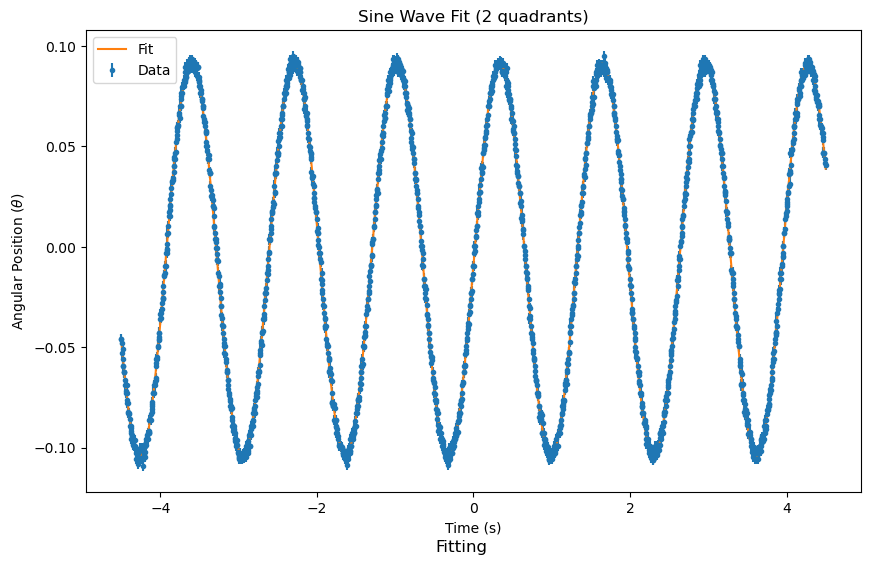

In [8]:
#KEY REMOVE FOR STUDENTS
#Import "2_quadrants.txt"
data = genfromtxt("2_quadrants.txt", delimiter='	', skip_header=2, invalid_raise=False)
t = data[:, 0] 
t_error = 0.0025
V = data[:, 1]
V_error = 0.004750 / 6

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, V, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time')
plt.figtext(0.5, 0.01, "Caption: Oscillator data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def sine_wave_2q(x, A, omega, phi0, C):
    y = A * np.sin(omega * x + phi0) + C
    return y

#Preliminarily Fit the Data
guess_A = 0.17
guess_omega = 4.8
guess_phi0 = -2.8
guess_C = -0.02


guess=np.array([guess_A, guess_omega, guess_phi0, guess_C])

uw_fits,uw_covs=curve_fit(sine_wave_2q, t, theta, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = uw_fits[1] * uw_fits[0] * np.cos(uw_fits[1] * t + uw_fits[2])

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(sine_wave_2q, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 4.0)) * np.sum(((theta - sine_wave_2q(t, fits[0], fits[1], fits[2], fits[3])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$\omega = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$\phi_0 = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$C = {fits[3]:.4f} \pm {stds[3]:.4f}$"))

#Plot the fit with the data!
fit_sine = sine_wave_2q(t, fits[0], fits[1], fits[2], fits[3])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_sine, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (2 quadrants)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

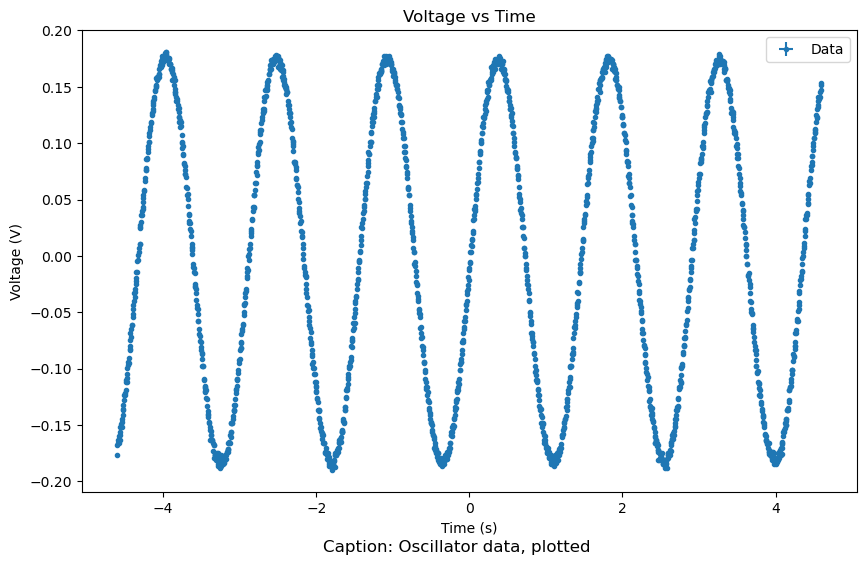

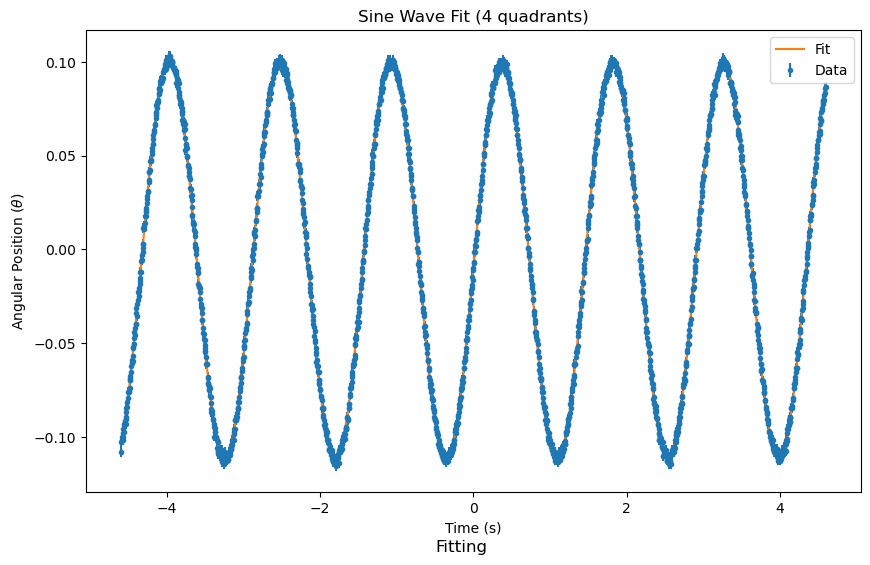

In [9]:
#KEY REMOVE FOR STUDENTS
#Import "4_quadrants.txt"
data = genfromtxt("4_quadrants.txt", delimiter='	', skip_header=2, invalid_raise=False)
t = data[:, 0] 
t_error = 0.0025
V = data[:, 1]
V_error = 0.004750 / 6

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, V, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time')
plt.figtext(0.5, 0.01, "Caption: Oscillator data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def sine_wave_4q(x, A, omega, phi0, C):
    y = A * np.sin(omega * x + phi0) + C
    return y

#Preliminarily Fit the Data
guess_A = 0.17
guess_omega = 4.2
guess_phi0 = -2.8
guess_C = -0.02


guess=np.array([guess_A, guess_omega, guess_phi0, guess_C])

uw_fits,uw_covs=curve_fit(sine_wave_4q, t, theta, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = uw_fits[1] * uw_fits[0] * np.cos(uw_fits[1] * t + uw_fits[2])

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(sine_wave_4q, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 4.0)) * np.sum(((theta - sine_wave_4q(t, fits[0], fits[1], fits[2], fits[3])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$\omega = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$\phi_0 = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$C = {fits[3]:.4f} \pm {stds[3]:.4f}$"))

#Plot the fit with the data!
fit_sine = sine_wave_4q(t, fits[0], fits[1], fits[2], fits[3])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_sine, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (4 quadrants)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

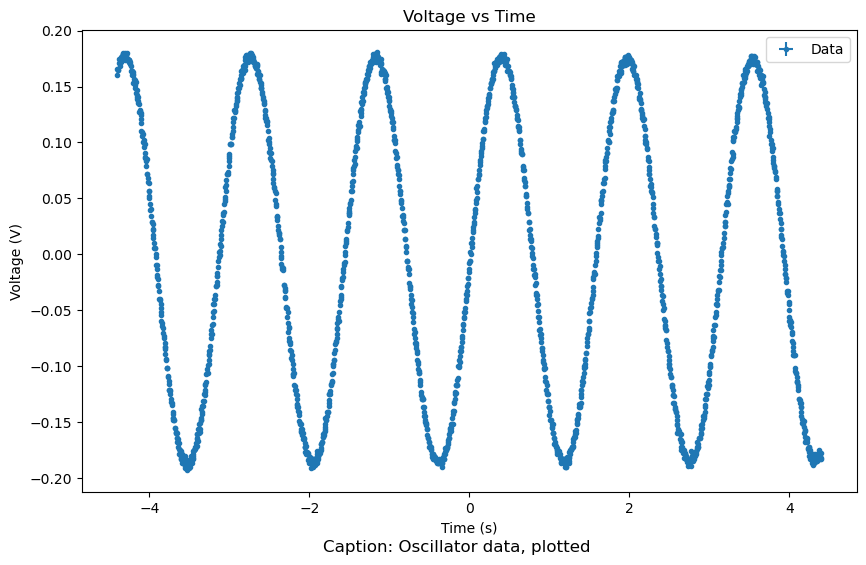

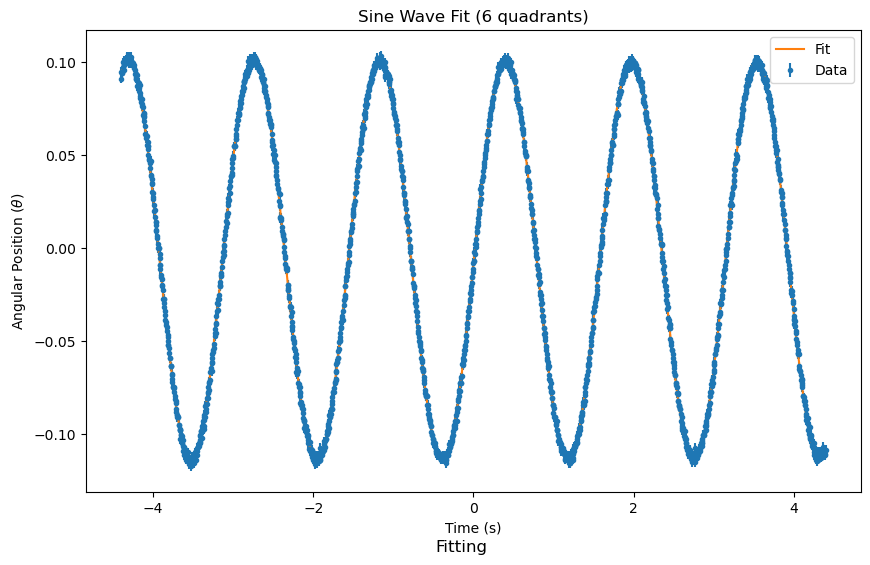

In [10]:
#KEY REMOVE FOR STUDENTS
#Import "6_quadrants.txt"
data = genfromtxt("6_quadrants.txt", delimiter='	', skip_header=2, invalid_raise=False)
t = data[:, 0] 
t_error = 0.0025
V = data[:, 1]
V_error = 0.004750 / 6

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, V, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time')
plt.figtext(0.5, 0.01, "Caption: Oscillator data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def sine_wave_6q(x, A, omega, phi0, C):
    y = A * np.sin(omega * x + phi0) + C
    return y

#Preliminarily Fit the Data
guess_A = 0.17
guess_omega = 4.2
guess_phi0 = -2.8
guess_C = -0.02


guess=np.array([guess_A, guess_omega, guess_phi0, guess_C])

uw_fits,uw_covs=curve_fit(sine_wave_6q, t, theta, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = uw_fits[1] * uw_fits[0] * np.cos(uw_fits[1] * t + uw_fits[2])

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(sine_wave_6q, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 4.0)) * np.sum(((theta - sine_wave_6q(t, fits[0], fits[1], fits[2], fits[3])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$\omega = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$\phi_0 = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$C = {fits[3]:.4f} \pm {stds[3]:.4f}$"))

#Plot the fit with the data!
fit_sine = sine_wave_6q(t, fits[0], fits[1], fits[2], fits[3])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_sine, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (6 quadrants)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

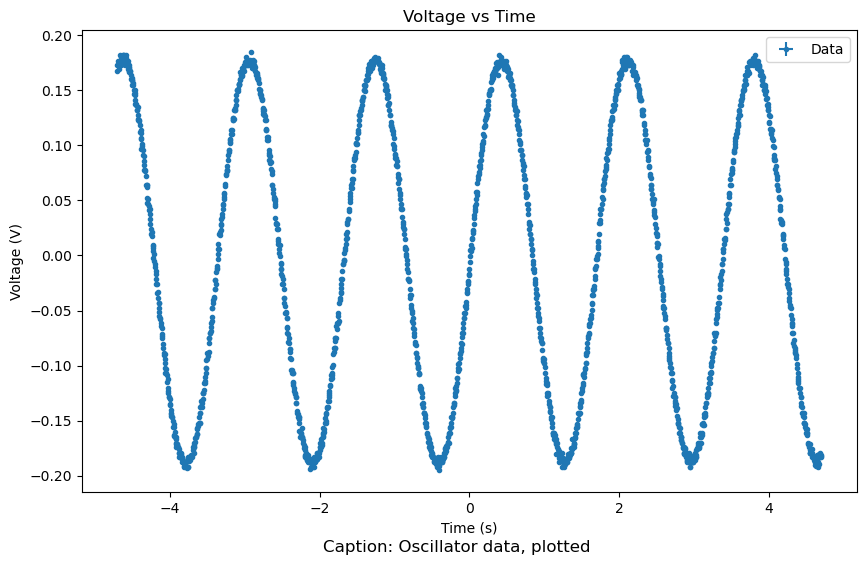

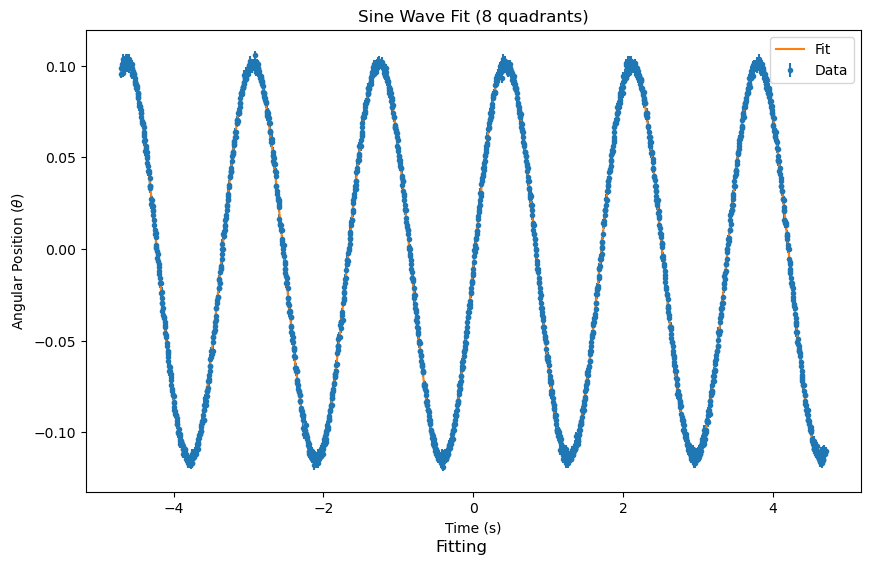

In [11]:
#KEY REMOVE FOR STUDENTS
#Import "8_quadrants.txt"
data = genfromtxt("8_quadrants.txt", delimiter='	', skip_header=2, invalid_raise=False)
t = data[:, 0] 
t_error = 0.0025
V = data[:, 1]
V_error = 0.004750 / 6

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, V, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time')
plt.figtext(0.5, 0.01, "Caption: Oscillator data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def sine_wave_8q(x, A, omega, phi0, C):
    y = A * np.sin(omega * x + phi0) + C
    return y

#Preliminarily Fit the Data
guess_A = 0.17
guess_omega = 3.8
guess_phi0 = -2.8
guess_C = -0.02


guess=np.array([guess_A, guess_omega, guess_phi0, guess_C])

uw_fits,uw_covs=curve_fit(sine_wave_8q, t, theta, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = uw_fits[1] * uw_fits[0] * np.cos(uw_fits[1] * t + uw_fits[2])

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(sine_wave_8q, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 4.0)) * np.sum(((theta - sine_wave_8q(t, fits[0], fits[1], fits[2], fits[3])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$\omega = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$\phi_0 = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$C = {fits[3]:.4f} \pm {stds[3]:.4f}$"))

#Plot the fit with the data!
fit_sine = sine_wave_8q(t, fits[0], fits[1], fits[2], fits[3])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_sine, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (8 quadrants)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

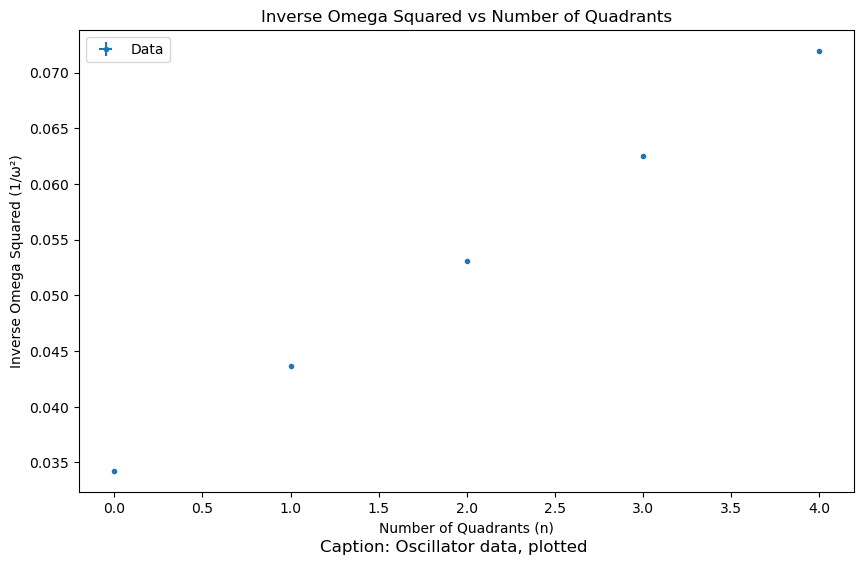

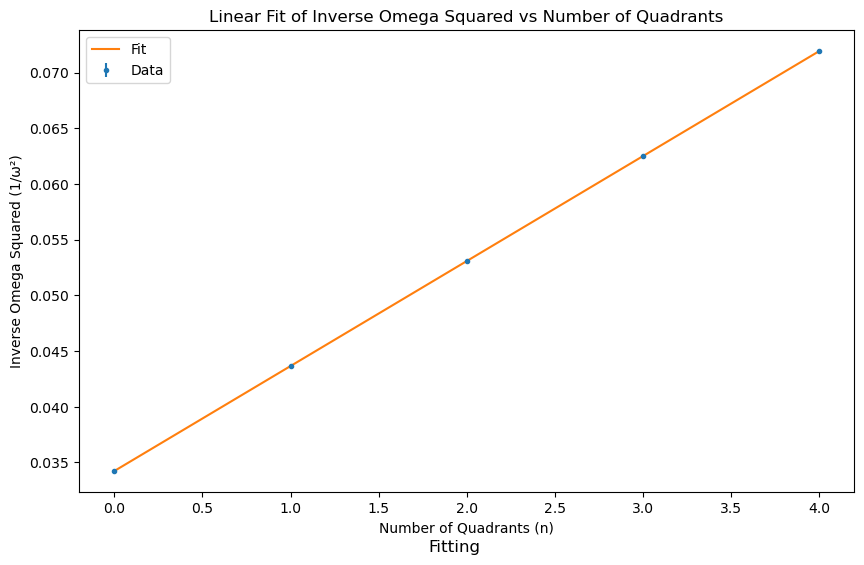

In [24]:
#KEY REMOVE FOR STUDENTS
#Import "omega_vs_n.txt"
data = genfromtxt("omega_vs_n.txt", delimiter=' ', skip_header=1, invalid_raise=False)
omega = data[:, 0] 
omega_error = data[:, 1]
n = data[:, 2]
n_error = 0

inverse_omega_squared = 1 / (omega**2)
inverse_omega_squared_error = (2 / omega**3) * omega_error

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(n, inverse_omega_squared, xerr=n_error, yerr=inverse_omega_squared_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Number of Quadrants (n)')
plt.ylabel('Inverse Omega Squared (1/ω²)')
plt.title('Inverse Omega Squared vs Number of Quadrants')
plt.figtext(0.5, 0.01, "Caption: Oscillator data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def linear(x, Iq_kappa, I0_kappa):
    y = Iq_kappa * x + I0_kappa
    return y

#Preliminarily Fit the Data
guess_Iq_kappa = 0.17
guess_I0_kappa = 3.8


guess=np.array([guess_Iq_kappa, guess_I0_kappa])

uw_fits,uw_covs=curve_fit(linear, n, inverse_omega_squared, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = uw_fits[0]

#Calculate total error
sigmas= np.sqrt(inverse_omega_squared_error**2 + (dy_dx * n_error)**2)

#Perform weighted fit
fits, covs=curve_fit(linear, n, inverse_omega_squared, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (n.size - 2.0)) * np.sum(((inverse_omega_squared - linear(n, fits[0], fits[1])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$\frac{{I_q}}{{\kappa}} = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$\frac{{I_0}}{{\kappa}} = {fits[1]:.4f} \pm {stds[1]:.4f}$"))

#Plot the fit with the data!
fit_line = linear(n, fits[0], fits[1])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(n, inverse_omega_squared, yerr=sigmas, fmt='.', label="Data")
plt.plot(n, fit_line, '-', label="Fit")
plt.legend()
plt.xlabel('Number of Quadrants (n)')
plt.ylabel(r'Inverse Omega Squared (1/ω²)')
plt.title('Linear Fit of Inverse Omega Squared vs Number of Quadrants')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

### Solving for the torsion constant and the moment of inertia of the rotor from the weighted fit of the data

In [35]:
d_o = 0.09301 # meters
r_o = d_o / 2 # meters
r_o_error = 0.00001 # meters
d_i = 0.04319 # meters
r_i = d_i / 2 # meters
r_i_error = 0.00001 # meters
m_q = 0.2140 # kilograms
m_q_error = 0.0001# kilograms

I_q = 0.5 * (2 * m_q) * (r_o**2 + r_i**2) # kilograms * meters^2
kappa = I_q / fits[0] 
I_0 = kappa * fits[1] 

I_q_error = np.sqrt((r_o**2 + r_i**2)**2 * m_q_error**2 + (2 * m_q * r_o)**2 * r_o_error**2 + (2 * m_q * r_i)**2 * r_i_error**2)
kappa_error = np.sqrt((1 / fits[0])**2 * I_q_error**2 + (I_q / fits[0]**2)**2 * stds[0]**2)
I_0_error = np.sqrt(fits[1]**2 * kappa_error**2 + kappa**2 * stds[1]**2)

display(Latex(fr"Moment of inertia of quadrants: $I_q = {I_q:.4f} \pm {I_q_error:.7f}$ kg·m²"))
display(Latex(fr"Torsion constant: $\kappa = {kappa:.4f} \pm {kappa_error:.4f}$ N·m/rad"))
display(Latex(fr"Moment of inertia of the rotor: $I_0 = {I_0:.4f} \pm {I_0_error:.6f}$ kg·m²"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## Linear damping

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

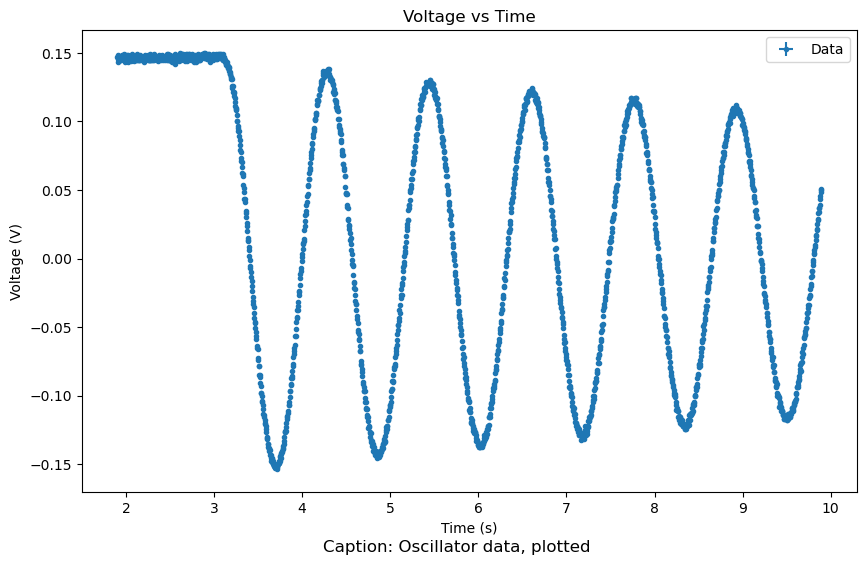

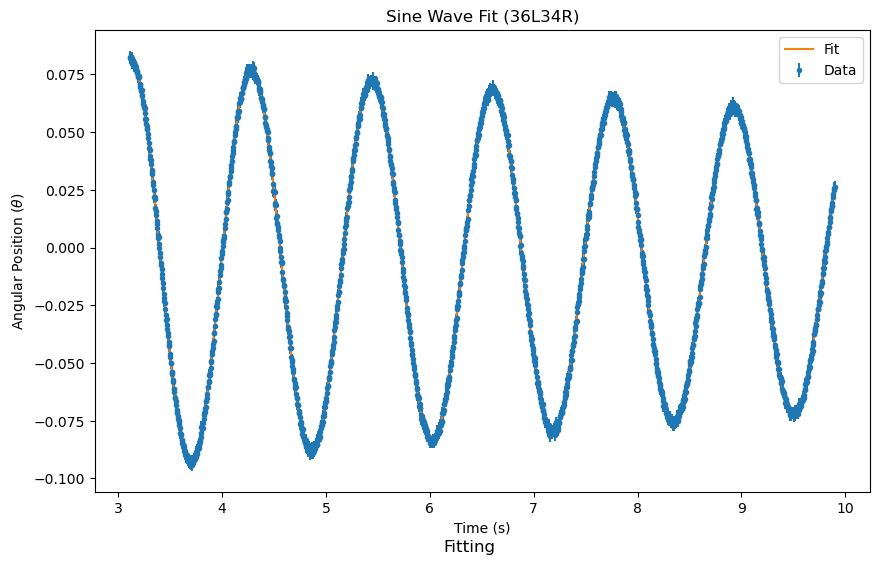

In [44]:
#KEY REMOVE FOR STUDENTS
#Import "LinearDamping36L34R.txt"
data = genfromtxt("LinearDamping36L34R.txt", delimiter='\t', skip_header=2, invalid_raise=False, encoding='utf-16')
t_raw = data[:, 0] 
t = t_raw[303:2002]
t_error = 0.002
V_raw = data[:, 1]
V = V_raw[303:2002]
V_error = 0.007425 / 6

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t_raw, V_raw, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time')
plt.figtext(0.5, 0.01, "Caption: Oscillator data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Linear_Damping(x, A, B, C, D, E):
    y = A * np.exp(-B * x) * np.cos(C * x - D) + E
    return y

#Preliminarily Fit the Data
guess_A = 0.1
guess_B = 0.1
guess_C = 5.2
guess_D = 0.0
guess_E = 0.03

guess=np.array([guess_A, guess_B, guess_C, guess_D, guess_E])

uw_fits,uw_covs=curve_fit(Linear_Damping, t, theta, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = -uw_fits[1] * uw_fits[0] *np.exp(-uw_fits[1] * t) * np.cos(uw_fits[2] * t - uw_fits[3]) - uw_fits[0] * np.exp(-uw_fits[1] * t) * np.sin(uw_fits[2] * t - uw_fits[3]) * uw_fits[2]

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(Linear_Damping, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 5.0)) * np.sum(((theta - Linear_Damping(t, fits[0], fits[1], fits[2], fits[3], fits[4])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$B = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$C = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$D = {fits[3]:.4f} \pm {stds[3]:.4f}$"))
display(Latex(fr"$E = {fits[4]:.4f} \pm {stds[4]:.4f}$"))

#Plot the fit with the data!
fit_sine = Linear_Damping(t, fits[0], fits[1], fits[2], fits[3], fits[4])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_sine, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (36L34R)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

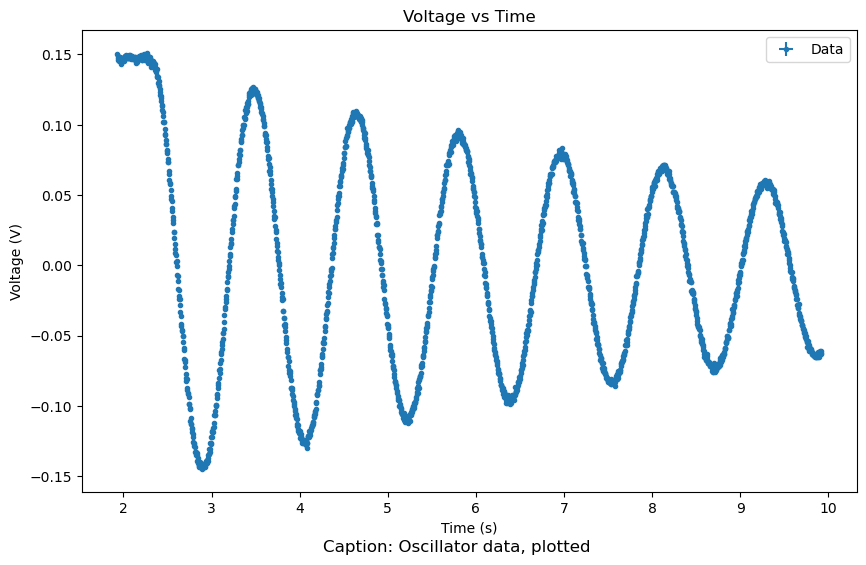

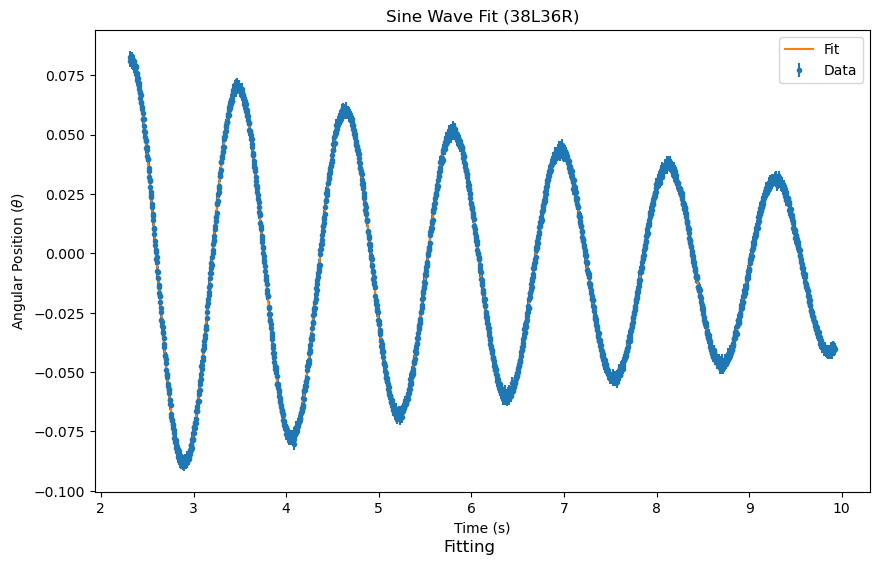

In [52]:
#KEY REMOVE FOR STUDENTS
#Import "LinearDamping38L36R.txt"
data = genfromtxt("LinearDamping38L36R.txt", delimiter=',', skip_header=2, invalid_raise=False)
t_raw = data[:, 0] 
t = t_raw[96:1999]
t_error = 0.002
V_raw = data[:, 1]
V = V_raw[96:1999]
V_error = 0.007425 / 6

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t_raw, V_raw, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time')
plt.figtext(0.5, 0.01, "Caption: Oscillator data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Linear_Damping(x, A, B, C, D, E):
    y = A * np.exp(-B * x) * np.cos(C * x - D) + E
    return y

#Preliminarily Fit the Data
guess_A = 0.1
guess_B = 0.1
guess_C = 5.2
guess_D = 0.0
guess_E = 0.03

guess=np.array([guess_A, guess_B, guess_C, guess_D, guess_E])

uw_fits,uw_covs=curve_fit(Linear_Damping, t, theta, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = -uw_fits[1] * uw_fits[0] *np.exp(-uw_fits[1] * t) * np.cos(uw_fits[2] * t - uw_fits[3]) - uw_fits[0] * np.exp(-uw_fits[1] * t) * np.sin(uw_fits[2] * t - uw_fits[3]) * uw_fits[2]

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(Linear_Damping, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 5.0)) * np.sum(((theta - Linear_Damping(t, fits[0], fits[1], fits[2], fits[3], fits[4])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$B = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$C = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$D = {fits[3]:.4f} \pm {stds[3]:.4f}$"))
display(Latex(fr"$E = {fits[4]:.4f} \pm {stds[4]:.4f}$"))

#Plot the fit with the data!
fit_sine = Linear_Damping(t, fits[0], fits[1], fits[2], fits[3], fits[4])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_sine, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (38L36R)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

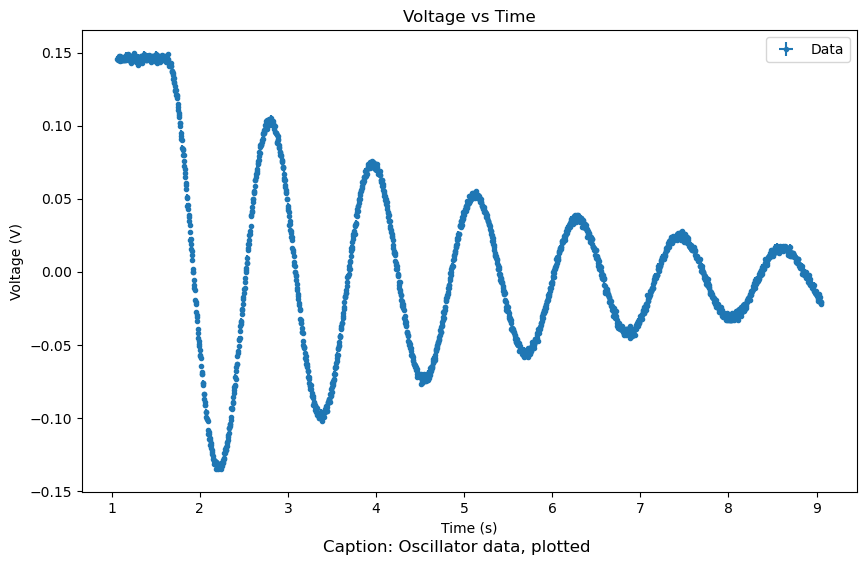

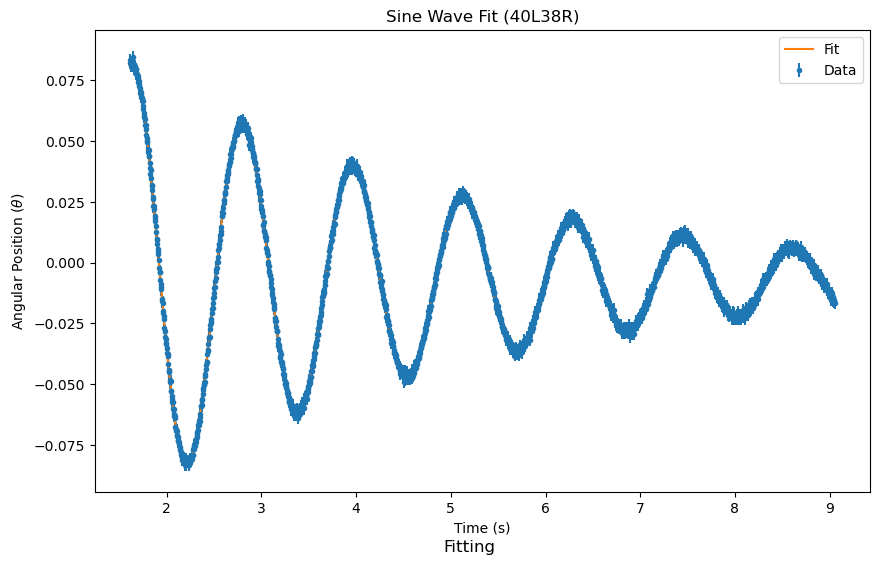

In [54]:
#KEY REMOVE FOR STUDENTS
#Import "LinearDamping40L38R.txt"
data = genfromtxt("LinearDamping40L38R.txt", delimiter=',', skip_header=2, invalid_raise=False)
t_raw = data[:, 0] 
t = t_raw[138:1999]
t_error = 0.002
V_raw = data[:, 1]
V = V_raw[138:1999]
V_error = 0.009450 / 6

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t_raw, V_raw, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time')
plt.figtext(0.5, 0.01, "Caption: Oscillator data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Linear_Damping(x, A, B, C, D, E):
    y = A * np.exp(-B * x) * np.cos(C * x - D) + E
    return y

#Preliminarily Fit the Data
guess_A = 0.1
guess_B = 0.1
guess_C = 5.2
guess_D = 0.0
guess_E = 0.03

guess=np.array([guess_A, guess_B, guess_C, guess_D, guess_E])

uw_fits,uw_covs=curve_fit(Linear_Damping, t, theta, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = -uw_fits[1] * uw_fits[0] *np.exp(-uw_fits[1] * t) * np.cos(uw_fits[2] * t - uw_fits[3]) - uw_fits[0] * np.exp(-uw_fits[1] * t) * np.sin(uw_fits[2] * t - uw_fits[3]) * uw_fits[2]

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(Linear_Damping, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 5.0)) * np.sum(((theta - Linear_Damping(t, fits[0], fits[1], fits[2], fits[3], fits[4])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$B = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$C = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$D = {fits[3]:.4f} \pm {stds[3]:.4f}$"))
display(Latex(fr"$E = {fits[4]:.4f} \pm {stds[4]:.4f}$"))

#Plot the fit with the data!
fit_sine = Linear_Damping(t, fits[0], fits[1], fits[2], fits[3], fits[4])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_sine, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (40L38R)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

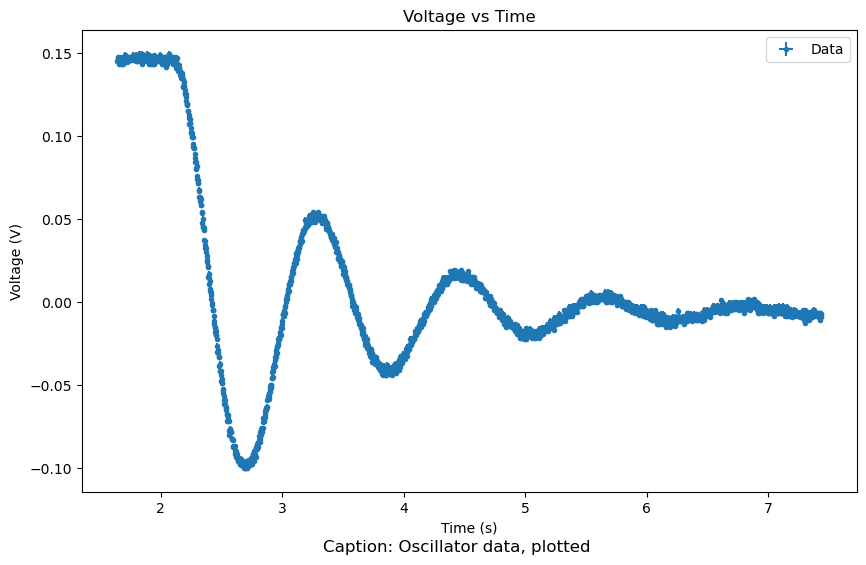

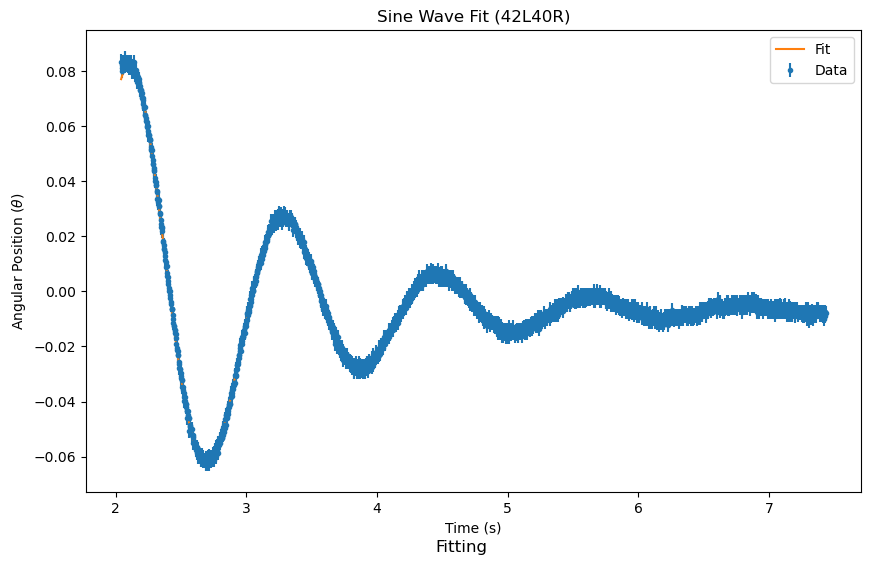

In [55]:
#KEY REMOVE FOR STUDENTS
#Import "LinearDamping42L40R.txt"
data = genfromtxt("LinearDamping42L40R.txt", delimiter=',', skip_header=2, invalid_raise=False)
t_raw = data[:, 0] 
t = t_raw[138:1999]
t_error = 0.002
V_raw = data[:, 1]
V = V_raw[138:1999]
V_error = 0.009450 / 6

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t_raw, V_raw, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time')
plt.figtext(0.5, 0.01, "Caption: Oscillator data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Linear_Damping(x, A, B, C, D, E):
    y = A * np.exp(-B * x) * np.cos(C * x - D) + E
    return y

#Preliminarily Fit the Data
guess_A = 0.1
guess_B = 0.1
guess_C = 5.2
guess_D = 0.0
guess_E = 0.03

guess=np.array([guess_A, guess_B, guess_C, guess_D, guess_E])

uw_fits,uw_covs=curve_fit(Linear_Damping, t, theta, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = -uw_fits[1] * uw_fits[0] *np.exp(-uw_fits[1] * t) * np.cos(uw_fits[2] * t - uw_fits[3]) - uw_fits[0] * np.exp(-uw_fits[1] * t) * np.sin(uw_fits[2] * t - uw_fits[3]) * uw_fits[2]

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(Linear_Damping, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 5.0)) * np.sum(((theta - Linear_Damping(t, fits[0], fits[1], fits[2], fits[3], fits[4])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$B = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$C = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$D = {fits[3]:.4f} \pm {stds[3]:.4f}$"))
display(Latex(fr"$E = {fits[4]:.4f} \pm {stds[4]:.4f}$"))

#Plot the fit with the data!
fit_sine = Linear_Damping(t, fits[0], fits[1], fits[2], fits[3], fits[4])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_sine, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (42L40R)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

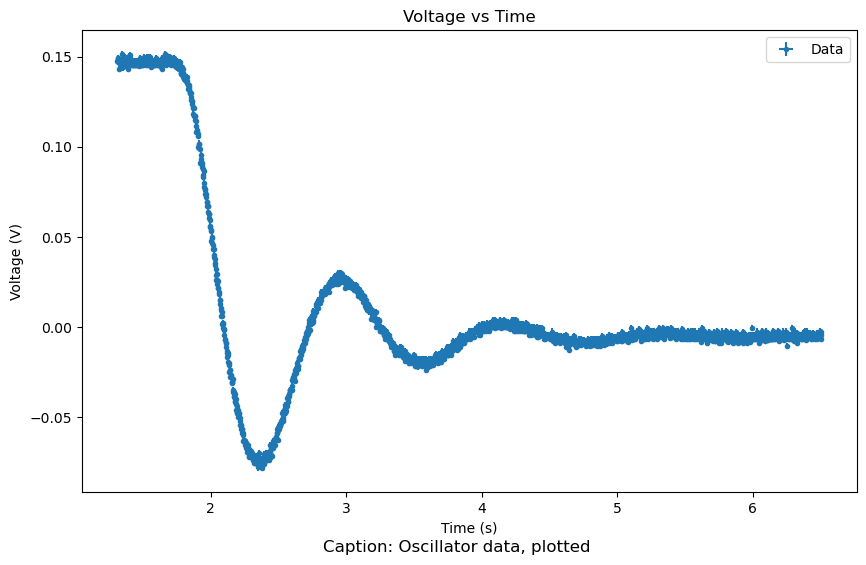

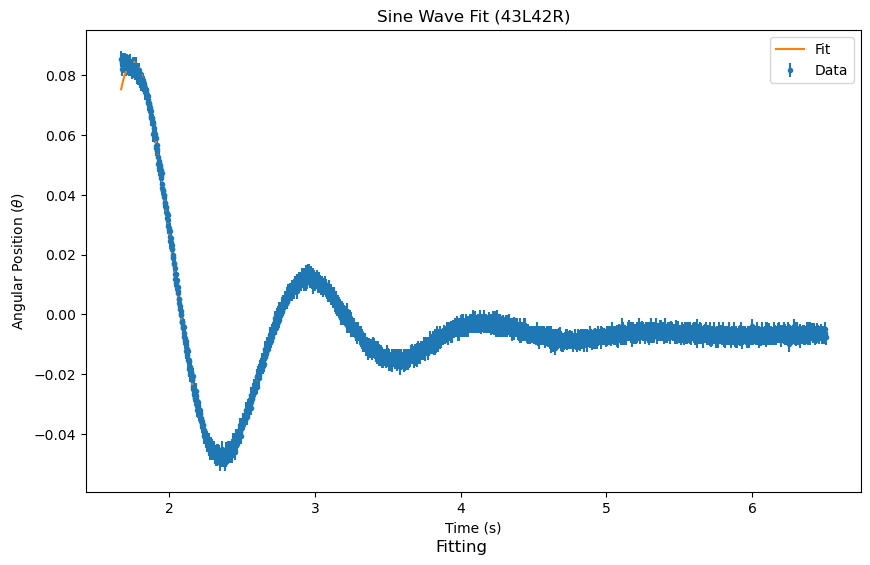

In [56]:
#KEY REMOVE FOR STUDENTS
#Import "LinearDamping43L42R.txt"
data = genfromtxt("LinearDamping43L42R.txt", delimiter=',', skip_header=2, invalid_raise=False)
t_raw = data[:, 0] 
t = t_raw[138:1999]
t_error = 0.002
V_raw = data[:, 1]
V = V_raw[138:1999]
V_error = 0.010125 / 6

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t_raw, V_raw, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time')
plt.figtext(0.5, 0.01, "Caption: Oscillator data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Linear_Damping(x, A, B, C, D, E):
    y = A * np.exp(-B * x) * np.cos(C * x - D) + E
    return y

#Preliminarily Fit the Data
guess_A = 0.1
guess_B = 0.1
guess_C = 5.2
guess_D = 0.0
guess_E = 0.03

guess=np.array([guess_A, guess_B, guess_C, guess_D, guess_E])

uw_fits,uw_covs=curve_fit(Linear_Damping, t, theta, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = -uw_fits[1] * uw_fits[0] *np.exp(-uw_fits[1] * t) * np.cos(uw_fits[2] * t - uw_fits[3]) - uw_fits[0] * np.exp(-uw_fits[1] * t) * np.sin(uw_fits[2] * t - uw_fits[3]) * uw_fits[2]

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(Linear_Damping, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 5.0)) * np.sum(((theta - Linear_Damping(t, fits[0], fits[1], fits[2], fits[3], fits[4])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$B = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$C = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$D = {fits[3]:.4f} \pm {stds[3]:.4f}$"))
display(Latex(fr"$E = {fits[4]:.4f} \pm {stds[4]:.4f}$"))

#Plot the fit with the data!
fit_sine = Linear_Damping(t, fits[0], fits[1], fits[2], fits[3], fits[4])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_sine, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (43L42R)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

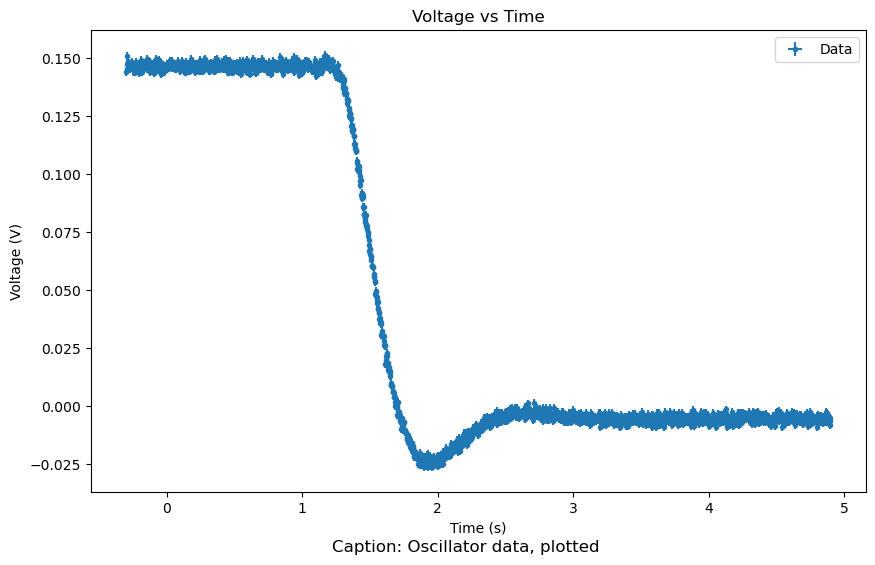

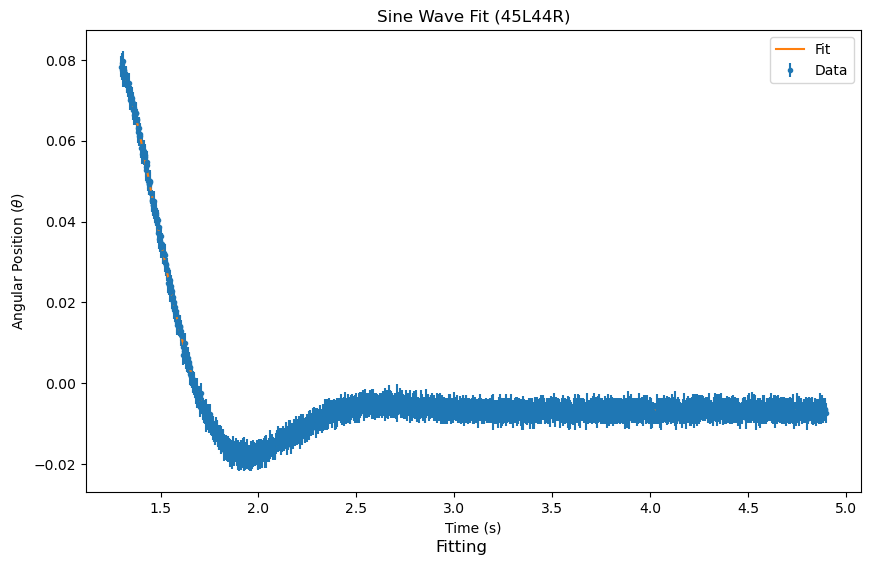

In [58]:
#KEY REMOVE FOR STUDENTS
#Import "LinearDamping45L44R.txt"
data = genfromtxt("LinearDamping45L44R.txt", delimiter=',', skip_header=2, invalid_raise=False)
t_raw = data[:, 0] 
t = t_raw[615:1999]
t_error = 0.002
V_raw = data[:, 1]
V = V_raw[615:1999]
V_error = 0.010125 / 6

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t_raw, V_raw, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time')
plt.figtext(0.5, 0.01, "Caption: Oscillator data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Linear_Damping(x, A, B, C, D, E):
    y = A * np.exp(-B * x) * np.cos(C * x - D) + E
    return y

#Preliminarily Fit the Data
guess_A = 0.1
guess_B = 0.1
guess_C = 5.2
guess_D = 0.0
guess_E = 0.03

guess=np.array([guess_A, guess_B, guess_C, guess_D, guess_E])

uw_fits,uw_covs=curve_fit(Linear_Damping, t, theta, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = -uw_fits[1] * uw_fits[0] *np.exp(-uw_fits[1] * t) * np.cos(uw_fits[2] * t - uw_fits[3]) - uw_fits[0] * np.exp(-uw_fits[1] * t) * np.sin(uw_fits[2] * t - uw_fits[3]) * uw_fits[2]

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(Linear_Damping, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 5.0)) * np.sum(((theta - Linear_Damping(t, fits[0], fits[1], fits[2], fits[3], fits[4])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$B = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$C = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$D = {fits[3]:.4f} \pm {stds[3]:.4f}$"))
display(Latex(fr"$E = {fits[4]:.4f} \pm {stds[4]:.4f}$"))

#Plot the fit with the data!
fit_sine = Linear_Damping(t, fits[0], fits[1], fits[2], fits[3], fits[4])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_sine, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (45L44R)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

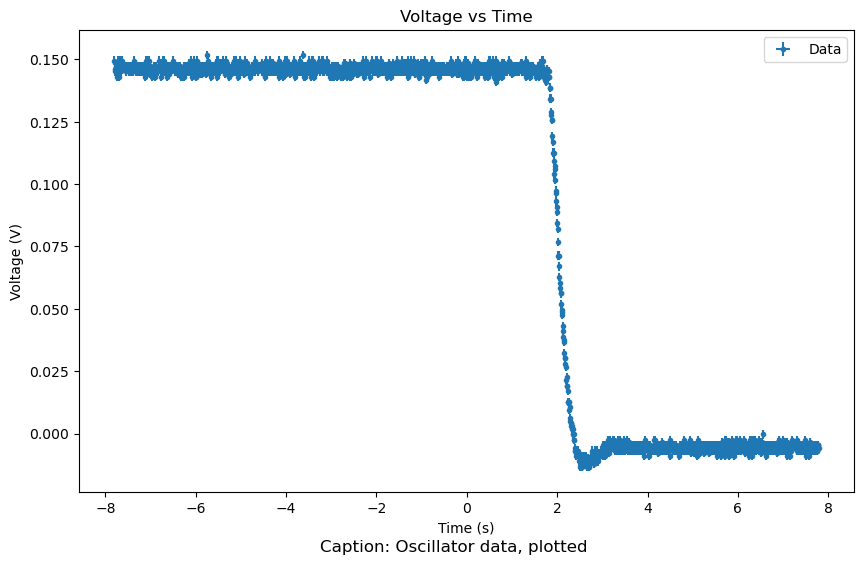

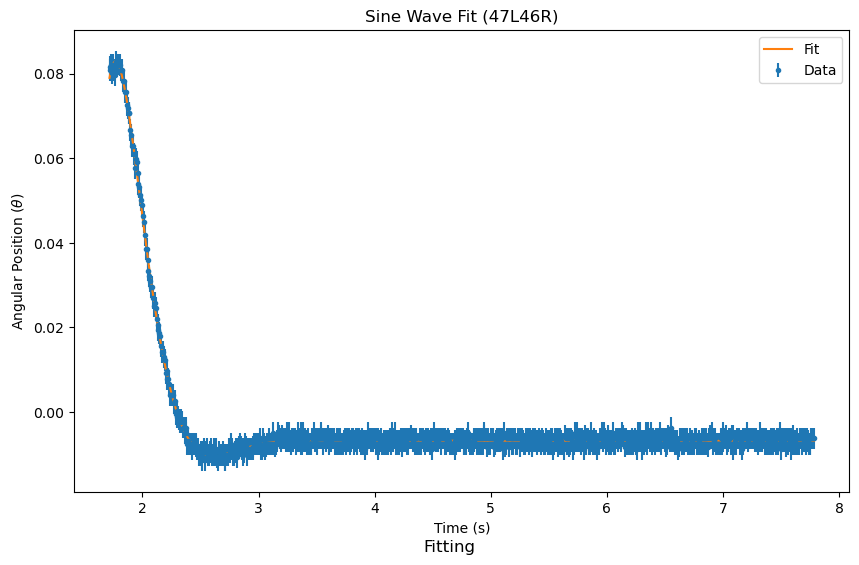

In [63]:
#KEY REMOVE FOR STUDENTS
#Import "LinearDamping47L46R.txt"
data = genfromtxt("LinearDamping47L46R.txt", delimiter=',', skip_header=2, invalid_raise=False)
t_raw = data[:, 0] 
t = t_raw[1220:1999]
t_error = 0.002
V_raw = data[:, 1]
V = V_raw[1220:1999]
V_error = 0.010125 / 6

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t_raw, V_raw, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time')
plt.figtext(0.5, 0.01, "Caption: Oscillator data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Linear_Damping(x, A, B, C, D, E):
    y = A * np.exp(-B * x) * np.cos(C * x - D) + E
    return y

#Preliminarily Fit the Data
guess_A = 0.1
guess_B = 0.1
guess_C = 5.2
guess_D = 0.0
guess_E = 0.0

guess=np.array([guess_A, guess_B, guess_C, guess_D, guess_E])

uw_fits,uw_covs=curve_fit(Linear_Damping, t, theta, p0=guess, maxfev=100000)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = -uw_fits[1] * uw_fits[0] *np.exp(-uw_fits[1] * t) * np.cos(uw_fits[2] * t - uw_fits[3]) - uw_fits[0] * np.exp(-uw_fits[1] * t) * np.sin(uw_fits[2] * t - uw_fits[3]) * uw_fits[2]

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(Linear_Damping, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 5.0)) * np.sum(((theta - Linear_Damping(t, fits[0], fits[1], fits[2], fits[3], fits[4])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$B = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$C = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$D = {fits[3]:.4f} \pm {stds[3]:.4f}$"))
display(Latex(fr"$E = {fits[4]:.4f} \pm {stds[4]:.4f}$"))

#Plot the fit with the data!
fit_sine = Linear_Damping(t, fits[0], fits[1], fits[2], fits[3], fits[4])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_sine, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (47L46R)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Text(0.5, 0.01, 'Fitting')

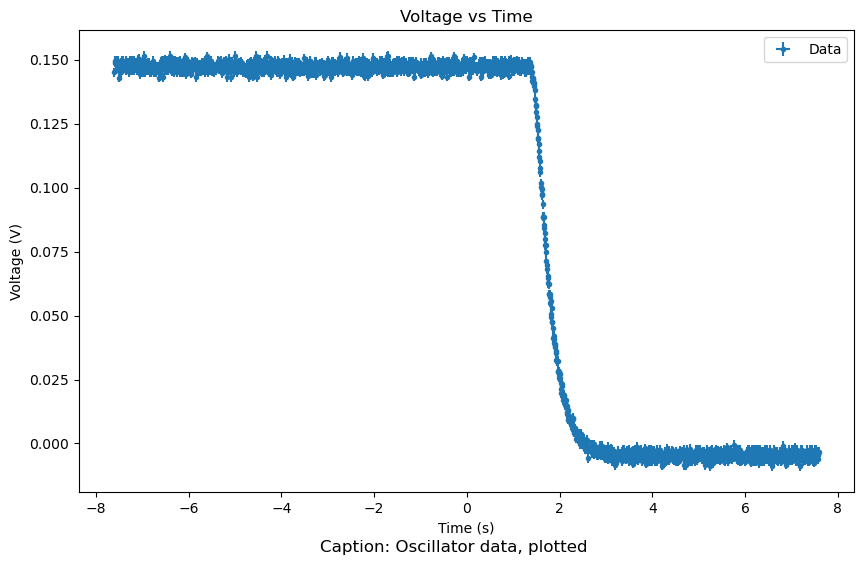

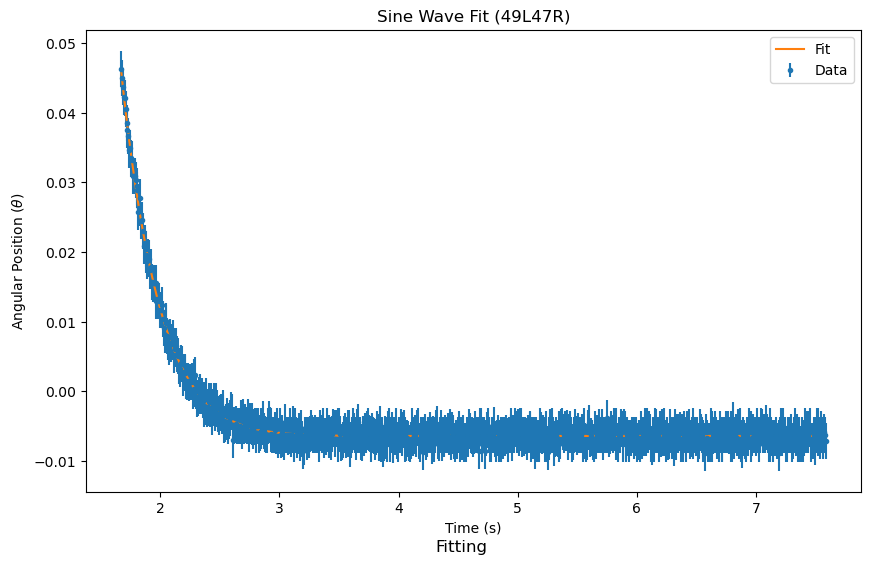

In [64]:
#KEY REMOVE FOR STUDENTS
#Import "LinearDamping49L47R.txt"
data = genfromtxt("LinearDamping49L47R.txt", delimiter=',', skip_header=2, invalid_raise=False)
t_raw = data[:, 0] 
t = t_raw[1220:1999]
t_error = 0.002
V_raw = data[:, 1]
V = V_raw[1220:1999]
V_error = 0.010800 / 6

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t_raw, V_raw, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time')
plt.figtext(0.5, 0.01, "Caption: Oscillator data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Linear_Damping(x, A, B, C, D, E):
    y = A * np.exp(-B * x) * np.cos(C * x - D) + E
    return y

#Preliminarily Fit the Data
guess_A = 0.1
guess_B = 0.1
guess_C = 5.2
guess_D = 0.0
guess_E = 0.0

guess=np.array([guess_A, guess_B, guess_C, guess_D, guess_E])

uw_fits,uw_covs=curve_fit(Linear_Damping, t, theta, p0=guess, maxfev=100000)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = -uw_fits[1] * uw_fits[0] *np.exp(-uw_fits[1] * t) * np.cos(uw_fits[2] * t - uw_fits[3]) - uw_fits[0] * np.exp(-uw_fits[1] * t) * np.sin(uw_fits[2] * t - uw_fits[3]) * uw_fits[2]

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(Linear_Damping, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 5.0)) * np.sum(((theta - Linear_Damping(t, fits[0], fits[1], fits[2], fits[3], fits[4])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$B = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$C = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$D = {fits[3]:.4f} \pm {stds[3]:.4f}$"))
display(Latex(fr"$E = {fits[4]:.4f} \pm {stds[4]:.4f}$"))

#Plot the fit with the data!
fit_sine = Linear_Damping(t, fits[0], fits[1], fits[2], fits[3], fits[4])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_sine, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (49L47R)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 1200.

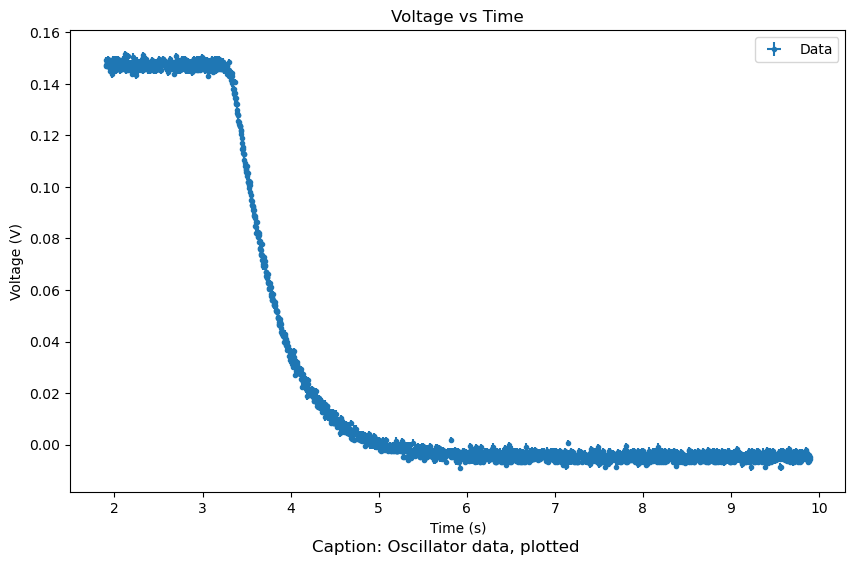

In [66]:
#KEY REMOVE FOR STUDENTS
#Import "LinearDamping51L49R.txt"
data = genfromtxt("LinearDamping51L49R.txt", delimiter=',', skip_header=2, invalid_raise=False)
t_raw = data[:, 0] 
t = t_raw[350:1999]
t_error = 0.002
V_raw = data[:, 1]
V = V_raw[350:1999]
V_error = 0.007425 / 6

m = 1.694
b = 0.006
m_error = 0.005
b_error = 0.004
theta = (1 / m) * V - (b / m)
theta_error = np.sqrt(((V - b) / m**2)**2 * m_error**2 + (1 / m)**2 * V_error**2 + (1 / m)**2 * b_error**2)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t_raw, V_raw, xerr=t_error, yerr=V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time')
plt.figtext(0.5, 0.01, "Caption: Oscillator data, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Linear_Damping(x, A, B, C, D, E):
    y = A * np.exp(-B * x) * np.cos(C * x - D) + E
    return y

#Preliminarily Fit the Data
guess_A = 0.1
guess_B = 0.1
guess_C = 5.2
guess_D = 0.0
guess_E = 0.0

guess=np.array([guess_A, guess_B, guess_C, guess_D, guess_E])

uw_fits,uw_covs=curve_fit(Linear_Damping, t, theta, p0=guess, maxfev=100000)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dy_dx
dy_dx = -uw_fits[1] * uw_fits[0] *np.exp(-uw_fits[1] * t) * np.cos(uw_fits[2] * t - uw_fits[3]) - uw_fits[0] * np.exp(-uw_fits[1] * t) * np.sin(uw_fits[2] * t - uw_fits[3]) * uw_fits[2]

#Calculate total error
sigmas= np.sqrt(theta_error**2 + (dy_dx * t_error)**2)

#Perform weighted fit
fits, covs=curve_fit(Linear_Damping, t, theta, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))

#Calculate reduced chi squared
Red_chi_sq = (1.0 / (t.size - 5.0)) * np.sum(((theta - Linear_Damping(t, fits[0], fits[1], fits[2], fits[3], fits[4])) / sigmas)**2)
display(Latex(fr"Reduced $\chi^2 =$ {Red_chi_sq}"))
display(Latex(fr"$A = {np.abs(fits[0]):.4f} \pm {stds[0]:.4f}$"))
display(Latex(fr"$B = {fits[1]:.4f} \pm {stds[1]:.4f}$"))
display(Latex(fr"$C = {fits[2]:.4f} \pm {stds[2]:.4f}$"))
display(Latex(fr"$D = {fits[3]:.4f} \pm {stds[3]:.4f}$"))
display(Latex(fr"$E = {fits[4]:.4f} \pm {stds[4]:.4f}$"))

#Plot the fit with the data!
fit_sine = Linear_Damping(t, fits[0], fits[1], fits[2], fits[3], fits[4])
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(t, theta, yerr=sigmas, fmt='.', label="Data")
plt.plot(t, fit_sine, '-', label="Fit")
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Position ($\theta$)')
plt.title('Sine Wave Fit (51L49R)')
plt.figtext(0.5, 0.01, "Fitting", wrap=True, horizontalalignment='center', fontsize=12)